# Geometric approach to the cryptanalysis of multivariate post-quantum signature schemes


Author: Pierre Pébereau
This SageMath notebook is designed to accompany my PhD thesis (https://theses.hal.science/tel-05605746), by providing examples of SageMath code mirroring examples and applications of the thesis.
In the Contributions part, it also demonstrates some of the algorithms developed in the related chapters.

It is designed so that each section can be run indepently, so you do not need to go through the whole notebook to run a later cell.

When we introduce a function, its code is included in the cell where it is used.
In later cells, we instead import it from the companion .sage files to keep the code concise.




# Part 1. Preliminaries


## Chapter 1. Computational algebraic geometry

In this chapter, we give some examples manipulating polynomials, matrices, ideals and varieties in SageMath which are used throughout the notebook. 
Note that very similarily to the theoretical aspect of cryptanalysis, we split attacks in two parts: a modelling part, which consists in writing down a polynomial system whose solutions reveal secret information, and a solving part, which consists in actually computing such solutions.

SageMath is very well adapted to the first task, as manipulating polynomials and matrices is relatively straightforward. However, dedicated polynomial system solving libraries (such as msolve, M4GB, Magma, ...) usually significantly outperform SageMath's solver, therefore in experiments, we almost always outsource this second step.

So as to not rely on external libraries, in order to keep this notebook self-contained, we instead only perform experiments on very small toy instances.


### Ideals and varieties

First, we define a finite field and a polynomial ring in which we can manipulate polynomials, matrices, ideals, ...

In [77]:
# Finite field
FF= GF(13)

# Dimension of the vector space
n = 4

# Polynomial ring
R = PolynomialRing(FF, 'X', n)
R.inject_variables(verbose=False)

# Hardcoding a polynomial 
p1 = -X0^2 + 5*X0*X1 + 4*X1^2 + X0*X2 - 5*X1*X2 + 6*X2^2 + 2*X0*X3 + 5*X1*X3 + X2*X3 - 4*X3^2
# Iteratively generating a random polynomial
p2 = sum([ FF.random_element()*xi*xj for xi in R.gens() for xj in R.gens()])

I = Ideal(p1,p2)
print(I)

Ideal (-X0^2 + 5*X0*X1 + 4*X1^2 + X0*X2 - 5*X1*X2 + 6*X2^2 + 2*X0*X3 + 5*X1*X3 + X2*X3 - 4*X3^2, 4*X0^2 - 4*X0*X1 - 2*X1^2 + 5*X0*X2 + 3*X1*X2 - 5*X2^2 + 3*X0*X3 - 4*X1*X3 - 3*X2*X3) of Multivariate Polynomial Ring in X0, X1, X2, X3 over Finite Field of size 13


### Dimension

Next, we demonstrate the behavior of dimension, and how to compute it in Sage.
Note that this computation may be quite expensive when the number of variables grows.

In [3]:
print("""I is generated by two polynomials in 4 variables.
We expect that V(I) has dimension m = 4 - 2 = 2.""")
print("dim(V(I))=",I.dimension()) 

print("We demonstrate Characterisation 1.10 by adding dim(V(I)) random linear forms.")

H = [ FF.random_element()+sum([FF.random_element()*x for x in R.gens()]) for _ in range(I.dimension())]
J = Ideal([p1,p2] + H)
print("dim(V(I) \\cap H)=", J.dimension())

print("When a variety has dimension 0, SageMath provides a function to compute the list of points in the variety over the base field.")
V = J.variety()
print(V)
print("The variety is a list of dictionnaries containing the coordinates of points. \nThis list may be empty when there are no rational solutions.")


I is generated by two polynomials in 4 variables.
We expect that V(I) has dimension m = 4 - 2 = 2.
dim(V(I))= 2
We demonstrate Characterisation 1.10 by adding dim(V(I)) random linear forms.
dim(V(I) \cap H)= 0
When a variety has dimension 0, SageMath provides a function to compute the list of points in the variety over the base field.
[{X3: 2, X2: 8, X1: 0, X0: 4}]
The variety is a list of dictionnaries containing the coordinates of points. 
This list may be empty when there are no rational solutions.


### Tangent space and Singular points

We illustrate the definition of tangent spaces using an example over the reals. 

We consider a curve of equation E: -X^3 + Y^2 + 3*X - 2 over R².
The Jacobian matrix of E has dimensions 1x2:

Jac_E(X,Y)= [-3*X^2 + 3        2*Y]

The point S = (1,0) belongs to the curve:
E(S) =  0
The Jacobian matrix evaluated at S has rank 0 . S is a singular point of the curve.
The point P = (0,sqrt(2)) belongs to the curve:
E(P) =  0
The Jacobian matrix evaluated at P has rank 1 . P is a regular point of the curve.
We compute the right kernel of the Jacobian matrix evaluated at P to obtain a vector D spanning the tangent line.
D = (4, -3*sqrt(2))
We plot the tangent line at P, and the point S.


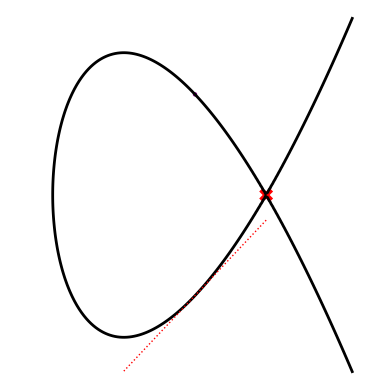

In [4]:
R = PolynomialRing(QQ, ['X','Y'], 2)
R.inject_variables(verbose=False)
E = Y**2 - X**3 + 3*X -2

print("We consider a curve of equation E:", E, "over R².")

J = matrix(E.gradient())
print("The Jacobian matrix of E has dimensions 1x2:")
print()
print("Jac_E(X,Y)=",J)
print()
S = (1, 0)
P = (0,sqrt(2))
print("The point S = (1,0) belongs to the curve:")
print("E(S) = ", E(X=S[0], Y=S[1]))
print("The Jacobian matrix evaluated at S has rank",J(X=S[0], Y=S[1]).rank(),". S is a singular point of the curve.")


print("The point P = (0,sqrt(2)) belongs to the curve:")
print("E(P) = ", E(X=P[0], Y=P[1]))
print("The Jacobian matrix evaluated at P has rank",J(X=P[0], Y=P[1]).rank(),". P is a regular point of the curve.")
print("We compute the right kernel of the Jacobian matrix evaluated at P to obtain a vector D spanning the tangent line.")
D = vector(4*J(X=P[0], Y=P[1]).right_kernel().basis_matrix())
print("D =",D)


print("We plot the tangent line at P, and the point S.")
var('t')
line_plot = parametric_plot((-4*t, -sqrt(2) - 3*sqrt(2)*t), (t, -.25, 0.25),color='red', linestyle="dotted")
implicit = implicit_plot(E, (X, -2.5, 2.5), (Y, -2.5, 2.5), color="black",  linewidth=2)
pt = point(P, color='purple')
pt2 = point(S, color='red', size = 100, marker= 'X')
combined_plot = implicit + line_plot + pt + pt2

combined_plot.show(axes=False, frame=False )


### Determinantal ideals

We display a few useful methods of matrices in SageMath and show that the bound of Theorem 1.34 is generically achieved.


In [5]:
n = 5
k = 2
l = 3
r = 2

# Polynomial ring
R = PolynomialRing(GF(31), 'X', n)

# Polynomial Matrix
M = matrix(R, k, l, [ R.random_element(degree=1) for _ in range(k*l)])
print(f"We sample a random polynomial M matrix of dimensions {k}x{l} in {n} variables.")
print(M)
print()
print(f"Sage provides a function to compute the minors of a certain degree of M, here are the {r}-minors:")
L = M.minors(r)
print(L)
print()
print("We can compute the codimension of this ideal, which is upper bounded by Theorem 1.34:")
print("codim J =",n-Ideal(L).dimension(),f"<= (k-r+1)(l-r+1) = {k-r+1}*{l-r+1}.")
print("For polynomial matrices with generic entries, it is known that this bound is achieved.")


We sample a random polynomial M matrix of dimensions 2x3 in 5 variables.
[   -8*X1 + 4*X2 + 9*X3 - 10*X4 - 3       -X0 + X1 - 14*X2 - 11*X4 - 8           -2*X0 - 4*X2 - 11*X4 - 1]
[14*X0 + 12*X1 - 4*X2 + 2*X3 - 9*X4      -2*X0 + 13*X1 - 4*X2 - X4 - 7    -2*X0 - 7*X1 - 5*X2 - 13*X4 + 5]

Sage provides a function to compute the minors of a certain degree of M, here are the 2-minors:
[14*X0^2 + 14*X0*X1 + 8*X1^2 - 2*X0*X2 + 8*X1*X2 - 10*X2^2 + 15*X0*X3 - 9*X1*X3 - 8*X2*X3 + 10*X0*X4 - 12*X1*X4 - 10*X2*X4 + 13*X3*X4 + 4*X4^2 - 6*X0 - 11*X1 + 14*X2 + 15*X3 + X4 - 10, -3*X0^2 + 9*X0*X1 - 6*X1^2 + 9*X0*X2 - 2*X1*X2 - 5*X2^2 - 14*X0*X3 - X1*X3 - 6*X2*X3 + X0*X4 - 4*X1*X4 + 11*X2*X4 - 2*X3*X4 - 11*X0 - 7*X1 - 15*X3 + 11*X4 - 15, -2*X0^2 - 7*X1^2 - 14*X0*X2 - 10*X1*X2 - 8*X2^2 + 11*X0*X4 - 10*X1*X4 + 3*X2*X4 + 8*X4^2 - 5*X0 + 12*X1 + 2*X4 + 15]

We can compute the codimension of this ideal, which is upper bounded by Theorem 1.34:
codim J = 2 <= (k-r+1)(l-r+1) = 1*2.
For polynomial matrices with 

### Gröbner bases

We give an example of a Gröbner basis computation using SageMath.


In [9]:
FF= GF(31) # Finite field
n = 5 # Dimension of the vector space
m = 4 # Number of polynomials

print("The ordering is chosen when creating the polynomial ring.")
print("Lexicographic Gröbner bases are very useful to find solutions to polynomial systems, \nas they contain univariate polynomials under reasonable assumptions.")
R = PolynomialRing(FF, 'X', n, order='lex') # Polynomial ring with lex order
print(R)
print()
print("We generate", m, "random homogeneous quadratic polynomials, and dehomogenize with X0=1.")
P = [ sum([ FF.random_element()*xi*xj for xi in R.gens() for xj in R.gens()])  for _ in range(m)]
P.append( R.gens()[0] - 1)
for p in P :
    print(p)
print()
print("SageMath enables us to compute a Gröbner bases of an ideal using Ideal().groebner_basis() (for the ordering chosen when defining the ring).")
I  = Ideal(P)
gb = I.groebner_basis()
for i in gb:
    print(i)
print()
print("Since the system is zero-dimensional, the last polynomial in the basis is univariate. \nThis enables us to find solutions in GF(q) by factoring this polynomial.")
print(gb[-1].factor())
print(Ideal(gb).variety())



The ordering is chosen when creating the polynomial ring.
Lexicographic Gröbner bases are very useful to find solutions to polynomial systems, 
as they contain univariate polynomials under reasonable assumptions.
Multivariate Polynomial Ring in X0, X1, X2, X3, X4 over Finite Field of size 31

We generate 4 random homogeneous quadratic polynomials, and dehomogenize with X0=1.
8*X0^2 + 6*X0*X1 - 15*X0*X2 - X0*X3 + 4*X0*X4 - 11*X1^2 - 10*X1*X2 - 13*X1*X3 - 6*X1*X4 - 8*X2^2 - 7*X2*X3 - 10*X3^2 + 4*X3*X4 - 10*X4^2
-2*X0^2 + 6*X0*X1 + 8*X0*X2 + 13*X0*X3 + 2*X0*X4 - 7*X1^2 + 7*X1*X2 + 10*X1*X3 - 8*X1*X4 - 5*X2^2 + 9*X2*X3 + 2*X2*X4 + 7*X3^2 + 3*X3*X4 + 6*X4^2
-6*X0^2 - 11*X0*X1 + 11*X0*X2 + 10*X0*X3 + 8*X0*X4 + 14*X1^2 + 5*X1*X2 - 15*X1*X3 - 6*X1*X4 + 14*X2^2 - X2*X4 - 7*X3^2 - 3*X3*X4 + 3*X4^2
7*X0^2 - X0*X1 + 2*X0*X3 + 5*X0*X4 - 4*X1^2 + 9*X1*X2 + X1*X3 + 5*X1*X4 + 13*X2^2 + 9*X2*X3 - 10*X2*X4 + 14*X3^2 - 15*X3*X4 + 14*X4^2
X0 - 1

SageMath enables us to compute a Gröbner bases of an ideal 

Sometimes, the grevlex Gröbner basis is enough to solve the problem at hand, for instance via Lemma 1.44.

We demonstrate this on a toy cryptographic example, UOV(n=10, m=4, o=4, q=251).

In [11]:
load('UOV.sage')
m = 4
n = 10
q = 251
_, P = KeyGen(q,m,n-m)
R = PolynomialRing(GF(q), 'X', n-1)
X = vector(list(R.gens())+[1]) # Dehomogenizing is important!
eqs = [X*p*X for p in P]
sys = eqs + list(jacobian(eqs, R.gens()).minors(m))
I = Ideal(sys) 
gb = I.groebner_basis()
print("The dehomogeneized (X9=1) public key is ")
for i in eqs:
    print(i)
    print()
print("The Gröbner basis of the singular locus of the previous quadratic polynomial system of 4 equations in 9 variables is a long sequence:")
print(gb)
print("But it contains n-m =",n-m,"linear polynomials:")
lin = []
for i in gb :
    if i.degree() == 1 :
        lin.append(i)
        print(i)
print("The variety of these linear polynomials is a vector space of solutions to the input polynomials. \nWe evaluate the system on a random point of this subspace:")
H = [ GF(q).random_element()+sum([GF(q).random_element()*x for x in R.gens()]) for _ in range(m-1)]
V0 = Ideal(lin+H).variety()[0]
x = X([V0[xi] for xi in R.gens()])
print('x=',x[1:])
for i in range(m):
    print("p"+str(i)+"(x) =", x*P[i]*x)
print("We show in Chapters 5 and 7 that it is precisely the UOV private key.")

The dehomogeneized (X9=1) public key is 
-72*X0^2 + 38*X0*X1 + 76*X1^2 - 18*X0*X2 + 71*X1*X2 + 24*X2^2 - 64*X0*X3 + 84*X1*X3 - 31*X2*X3 + 3*X3^2 - 121*X1*X4 - 42*X2*X4 + 12*X3*X4 + 114*X4^2 + 74*X0*X5 - 53*X1*X5 - 120*X2*X5 - 86*X3*X5 - 3*X4*X5 + 19*X5^2 - 34*X0*X6 - 32*X1*X6 - 116*X2*X6 + 72*X3*X6 + 54*X4*X6 + 108*X5*X6 - 13*X6^2 - 7*X0*X7 - 28*X1*X7 + 125*X2*X7 - 45*X3*X7 - 102*X4*X7 - 84*X5*X7 - 13*X6*X7 + 84*X7^2 - 87*X0*X8 - 20*X1*X8 + 23*X2*X8 - 74*X3*X8 + 55*X4*X8 - 109*X5*X8 - 59*X6*X8 + 80*X7*X8 + 13*X8^2 - 116*X0 + 27*X1 - 116*X2 + 125*X3 + 26*X4 - 45*X5 - 33*X6 + 72*X7 - 84*X8 + 85

-117*X0^2 - 53*X0*X1 + 114*X1^2 + 2*X0*X2 - 21*X1*X2 + 85*X2^2 - 21*X0*X3 + 50*X1*X3 - 100*X2*X3 + 42*X3^2 + 123*X0*X4 + 123*X1*X4 + 122*X2*X4 - 120*X3*X4 + 105*X4^2 - 91*X0*X5 + 119*X1*X5 + 34*X2*X5 + 104*X3*X5 - 74*X4*X5 - 75*X5^2 - 124*X0*X6 - 48*X1*X6 + 83*X2*X6 + 111*X3*X6 + 20*X4*X6 + 93*X5*X6 + 80*X6^2 - 95*X0*X7 + 79*X1*X7 - 10*X2*X7 + 82*X3*X7 + 16*X4*X7 + 96*X5*X7 + 10*X6*X7 - 112*X7^2 

### Hilbert Series

We demonstrate some SageMath methods enabling the computation of Hilbert Series and use them to demonstrate elementary properties of these objects.
For convenience and by a small abuse of notation, the methods are typically Ideal.hilbert_series(), while the formal definition would suggest (Ring/Ideal).hilbert_series(). 
You may have already noticed that the same thing happens with Ideal.dimension(), which is not the Krull dimension of the ideal but the dimension of (Ring/Ideal), i.e. the dimension of the variety.


In [12]:
print("We can use Hilbert series to predict the complexity of computing a Gröbner basis for a specific family of polynomial systems of equations.")
print("Consider a system of 4 homogeneous quadratic polynomials in 4 variables.")
m = 4
n = 4
q = 31
R = PolynomialRing(GF(q), 'X', n)
P = [ sum([ GF(q).random_element()*xi*xj for xi in R.gens() for xj in R.gens()])  for _ in range(m)]
for p in P:
    print(p)
print()
print("The polynomials are drawn uniformly at random, thus we expect that they form a regular sequence, and hence that the Hilbert series of R/I is ")
print("  (1-t^2)^m/(1-t)^n.")
HS_sage = Ideal(P).hilbert_series()
print("Indeed, Sage obtains the following Hilbert series for R/I:", HS_sage.factor())
print("Note that computing a Hilbert series in practice is in general as expensive as computing a Gröbner basis.")
print()
print("The degree of regularity is the maximal degree of an element in a grevlex Gröbner basis (Lemma 1.49), and the first non-positive index in the series (Prop. 1.52).")

PS = PowerSeriesRing(ZZ, 't', default_prec=40)
PS.inject_variables(verbose=False)
HS = (1-t^2)^m/((1-t)^n)
print("H(t)=",HS)
print('Thus, we expect a degree of regularity of 5, which achieves the Macaulay bound (Th. 1.50): 4 + 1.')
print("We verify this prediction by computing a Gröbner basis:")
I = Ideal(P)
gb = I.groebner_basis()
for i in gb:
    print(i, f"(degree {i.degree()})")
print("Indeed, 5 is the highest degree in a polynomial of the Gröbner basis.")

We can use Hilbert series to predict the complexity of computing a Gröbner basis for a specific family of polynomial systems of equations.
Consider a system of 4 homogeneous quadratic polynomials in 4 variables.
-9*X0^2 + 13*X0*X1 - 15*X1^2 + 12*X0*X2 + 6*X1*X2 + 10*X2^2 - 13*X0*X3 + 4*X1*X3 - 3*X2*X3 - 10*X3^2
-13*X0^2 - 9*X0*X1 + 9*X1^2 - 15*X0*X2 - 12*X1*X2 - 11*X2^2 + 4*X0*X3 - 13*X1*X3 + 7*X2*X3 - 5*X3^2
13*X0^2 - 12*X0*X1 + 4*X1^2 + X0*X2 - 10*X1*X2 + 6*X2^2 - 6*X0*X3 - 14*X2*X3 - 6*X3^2
15*X0^2 - 8*X0*X1 + 11*X1^2 + 7*X0*X2 - 6*X1*X2 + 11*X2^2 - 12*X0*X3 - 11*X1*X3 - 3*X2*X3 - 13*X3^2

The polynomials are drawn uniformly at random, thus we expect that they form a regular sequence, and hence that the Hilbert series of R/I is 
  (1-t^2)^m/(1-t)^n.
Indeed, Sage obtains the following Hilbert series for R/I: (t + 1)^4
Note that computing a Hilbert series in practice is in general as expensive as computing a Gröbner basis.

The degree of regularity is the maximal degree of an element 

# Chapter 2. Quadratic forms


## Quadric Normal Form
We implement and demonstrate the algorithm described in Theorem 2.11.

In [79]:
load('normal.sage')

print("Detailed algorithm on a small example.")
print("We begin with an arbitrary symmetric matrix, and detail the matrix of the quadratic form at each step of the algorithm, which is a completing-the-square method.")

n = 6
q = 31
P = random_matrix(GF(q), n , n )
P = P + P.T


def quadric_normal_form(g, verbose = False, randomize=False) :
    """
    g is a (square) matrix representing a quadratic form, not necessarily symmetric. V(<x^Tgx>) is the quadric represented by the quadratic form g.
    g admits a diagonalisation:
    there exists a matrix A s.t. g(Ax) = x_1^2 + ... + + x_n-1^2 + ax_n^2, but only in characteristic different from 2.
    We return this matrix.
    """
    #Definitions
    FF = g.base_ring()
    q = FF.characteristic()
    if q == 2 :
        raise Exception("Ill-defined in characteristic 2.")
    n = g.dimensions()[0]
    A = matrix(FF,g) #Work copy of g
    B = matrix.identity(n) #Change of variables
    if randomize :
        B = matrix(FF, complete_basis([], FF**n))
        A = B.transpose()*A*B
    if verbose :
        print(A,'\n')
    #First, we make sure there is no zero on the diagonal of g:
    first_zero = n #Index of the first zero on the diagonal. 
    indices = []
    for i in range(n) :
        if g[i,i] == 0 :
            indices.append(i)
    for i in indices :
        j = find_N(A, i)
        if j != -1 :
            t = N(i,j,n)
        else : 
            t =  S(i,first_zero-1,n)
            first_zero-=1
        B = B*t
        A = t.transpose()*A*t 
        if verbose :
            print(A,'\n')
    #Now, we construct the triangular change of variables that turns A into a diagonal matrix.
    C = matrix(FF,n,n)
    
    for i in range(n-1) :
        
        if A[i,i] == 0 :
            if A[i+1,i+1] != 0 :
                j = i +1
            else :
                j = i+2
                while j < n :
                    if A[j,j]==0:
                        j+=1
                    else :
                        break 
            if j < n :
                t = S(i,j,n) 
                B=B*t 
                A = t.transpose()*A*t 
        C = matrix.identity(FF,n)
        for j in range(i+1,n) :
            if A[i,i] == 0 and A[i+1,i+1] == 0 and A[i,i+1] !=0 and A[i+1,i] != 0 : #hyperbolic square
                t = M2(i,i+1,1,1,n)
                B=B*t
                A = t.transpose()*A*t 
                if verbose :
                    print(A,'\n')
            C[i,j] = (A[i,j] + A[j,i])/(2*A[i,i]) #We do not assume symmetry, and A[i,i] is non-zero by the previous work and assertion.
        
        C1 = C.inverse()
        A = C1.transpose()*A*C1 
        B = B*C1
        if verbose :
            print(A,'\n')
   #We normalize each entry to one if they are squares.
    
    for i in range(n) :
        if A[i,i] == 0 :
            continue 
        if kronecker(A[i,i]**(-1), q) == 1 :
            C = matrix.identity(FF,n)
            C[i,i] = sqrt(A[i,i]**(-1))
            A = C.transpose()*A*C
            B = B*C
            if verbose :
                print(A,'\n')
    #We put all non square entries (ie anything that is not a one at this point) at the end of the diagonal
    first_non_square = n-1
    while first_non_square > 0 and legendre_symbol(A.diagonal()[first_non_square],q) == -1 :
        first_non_square-=1
    
    for i in range(n) : 
        if A[i,i] != 1 :
            if first_non_square < 0 or i >= first_non_square:
                break
            #swap 
            while A[first_non_square,first_non_square] != 1 and first_non_square > 0:
                first_non_square-=1 
            C = S(i,first_non_square,n)
            first_non_square-=1
            A = C.transpose()*A*C
            B = B*C
            if verbose :
                print(A,'\n')
            while legendre_symbol(A.diagonal()[first_non_square],q) == -1 :
                first_non_square-=1
    
    if first_non_square == n-1 : #If we have only squares, then the diagonal is currently the identity.
        return B 

    #Now we aim to turn the remaining non-ones to ones, except at most one. 
    #For this, we pair them up sequentially and do a simple change of variables. 
        
    for i in range(first_non_square+1,n-1,2) :
        if A[i,i] == 0 :
            continue 
        try :
            C = matrix.identity(FF,n)
            C[i,i] = sqrt(A.diagonal()[i]**(-1)*A.diagonal()[i+1])
            if C.determinant() == 0 : 
                continue
            A = C.transpose()*A*C
            B = B*C
            if verbose :
                print(A,'\n')
        except :
            pass
        a = A.diagonal()[i]
        b = A.diagonal()[i+1]
        x,y = root_solution(a,b,1,q)
        if x == 0 and y == 0 :
            continue 
        C = M2(i,i+1,x,y,n)
        A = C.transpose()*A*C
        B = B*C
        if verbose :
            print(A, '\n')
            
    #In case the form is degenerate, we put the zeros in front to facilitate the computation of isotropic subspaces.  
    first_zero = 0
    while A.diagonal()[first_zero] == 0 : 
        first_zero+=1
    for i in range(first_zero,n) :
        if A.diagonal()[i] == 0 :
            C = S(first_zero, i, n )
            A = C.transpose()*A*C 
            B= B* C 
            if verbose :
                print(A,'\n',B.rank(),'\n')
            while A[first_zero,first_zero]==0:
                first_zero+=1
    return B


B = quadric_normal_form(P, verbose=True)
print("The matrix of the change of variables is")
print(B)

Detailed algorithm on a small example.
We begin with an arbitrary symmetric matrix, and detail the matrix of the quadratic form at each step of the algorithm, which is a completing-the-square method.
[22 13  5  5  0  7]
[13  4 28 17 25 29]
[ 5 28  9  2 20 19]
[ 5 17  2 22  1 20]
[ 0 25 20  1  9  6]
[ 7 29 19 20  6 25] 

[22  0  0  0  0  0]
[ 0  9 18  7 25 15]
[ 0 18 29 22 20 16]
[ 0  7 22 11  1 17]
[ 0 25 20  1  9  6]
[ 0 15 16 17  6 27] 

[22  0  0  0  0  0]
[ 0  9  0  0  0  0]
[ 0  0 24  8  1 17]
[ 0  0  8  9 16 26]
[ 0  0  1 16  5 16]
[ 0  0 17 26 16  2] 

[22  0  0  0  0  0]
[ 0  9  0  0  0  0]
[ 0  0 24  0  0  0]
[ 0  0  0 27 26 10]
[ 0  0  0 26 14 14]
[ 0  0  0 10 14 30] 

[22  0  0  0  0  0]
[ 0  9  0  0  0  0]
[ 0  0 24  0  0  0]
[ 0  0  0 27  0  0]
[ 0  0  0  0 28 17]
[ 0  0  0  0 17 24] 

[22  0  0  0  0  0]
[ 0  9  0  0  0  0]
[ 0  0 24  0  0  0]
[ 0  0  0 27  0  0]
[ 0  0  0  0 28  0]
[ 0  0  0  0  0 17] 

[22  0  0  0  0  0]
[ 0  1  0  0  0  0]
[ 0  0 24  0  0  0]
[ 0  0  

# Chapter 3. Unbalanced Oil and Vinegar Signatures

## Naive implementation of UOV

We implement a simple version of the UOV scheme, which is not optimized nor protected against side-channel attacks.
This will be used to test our attacks on random UOV public keys of various dimensions.

This implementation follows Definition 3.1.

A signature scheme is composed of 3 algorithms:
 - KeyGen, which takes as input a parameter set (and eventually a seed), and returns a pair (private key, public key).
 - Sign, which takes as input a private key, a message, and returns a signature of the message accepted by the corresponding public key.
 - Verify, which takes as input a public key, a message, a signature, and returns a boolean whose value determines if the signature is valid for the input public key.
 

In [14]:
load("UOV.sage")
print("We consider toy parameters (n, m, o, q) = (10, 4, 4, 31).")
n = 10
m = 4
o = 4
q = 31
print("KeyGen enables a signer to generate a (public key, private key) pair.")

def KeyGen(q,o,v, m=None, verbose = False):
    """
    This function generates a key pair for UOV parameters o,v where o is the dimension of the oil subspace and v the dimension of the vinegar subspace.
    By default, m=o, but the optional parameter m controls the number of polynomials generated. 
    To do this, we sample random matrices with a block of zero of size to produce the private key.
    We sample a random invertible change of variables A, compute G = F circ A, and return the pair (A,F), G.
    (A,F) is the UOV private key, G is the UOV public key. The corresponding systems are obtained by evaluating the quadratic forms over FF[x1,...,xn].
    Important notice: This code is a demonstration tool and should not used for applications where security matters. 
    """
    if m is None :
        m = o
    n = o+v 
    FF = GF(q)
    RR = None 
    if verbose :
        RR = PolynomialRing(FF, 'x', n)
    
    #Define A
    A = matrix.identity(FF,n)
    for i in range(n-o) :
        for j in range(o) :
            A[n-1-i,j] = FF.random_element()
            
    #Define F, G
    F = []
    G = []
    for e in range(m):
        Fe = matrix(FF, n, n)
        B0 = matrix(FF,o,o)
        B1 = random_matrix(FF,o,v)
        B2 = random_matrix(FF,v,o)
        B3 = random_matrix(FF,v,v)
        Fe = block_matrix([[B0,B1],[B2,B3]])
        
        if FF.characteristic() != 2 : 
            Fe = FF(2)**(-1)*(Fe+Fe.transpose())
        Ge = A.transpose()*Fe*A
        F.append(Fe)
        G.append(Ge)
        
    if verbose :
        print("The public key system is:")
        x = vector(RR.gens())
        for Ge in G :
            print(x*Ge*x)
    return (A,F), G

(A,F), G = KeyGen(q, m, n-o)

print(f"The public key is composed of {m} matrices of dimension {n}x{n} which represent quadratic forms.")
for g in G :
    print(g)
    print()
print("The private key is a pair of a sequence of secret quadratic forms, and a change of variables A:")
print(A)
print()
print("The second algorithm provided in a signature scheme enables the signer to sign an arbitrary target.")
print(f"In UOV, a target is an element of Fq^m = F{q}^{m} obtained by hashing the message, a string of arbitrary length in (0,1)^*.")
t = vector([GF(q).random_element() for _ in range(m)])
print("t=",t)


def Sign(PrK, M, depth = 0, verbose = False): 
    """
    Given a UOV private key (A,F), a target M, and a maximum number of allowed signature fails, attempt to produce a valid signature X of M.
    """

    max_depth = 10 #Fail after 10 retries (arbitrary value). Probability : (p_failure)^10 
    if depth > max_depth:
        raise Exception("The signature procedure has failed.")
    
    A,F = PrK
    q = A.base_ring().cardinality()
    m = len(F)
    n = F[0].dimensions()[0]
    v = n-m
    A_1 = A.inverse()
    FF = GF(q)
    RR = PolynomialRing(FF, 'x', m)
    X = RR.gens()

    #Generate random values for vinegar variables.
    Y_2 = [FF.random_element() for _ in range(v)]

    Y = vector(RR, list(X) + Y_2)

    #Use linear algebra to solve for oil variables.
    system = []
    for e in range(m):
        system.append(Y*F[e]*Y)
    if verbose:
        print("The signer solves the system: ", system)
    #This system is linear in x_1, ..., x_k 
    mat = [ [ 0 for _ in range(m)] for _ in range(m)]
    for i in range(m) :
        for j in range(m) :
            mat[i][j] = system[i].coefficient(X[j])

    S = matrix(FF, mat)
    B = vector([system[i]([0 for _ in range(m)]) for i in range(m)])
    target = M-B 

    try: 
        Y_1 = S.solve_right(target)
    except:
        print("The system is not invertible, we try again with different random values.")
        return Sign(PrK, M, depth+1, verbose) 
    Y_hat = vector(FF, list(Y_1) + Y_2) #Recombination
    
    if verbose :
        print("Number of retries : ", depth)
    
    #Use Secret Key to return an 'X' solution.
    return A_1*Y_hat

x = Sign((A,F),t, verbose=True)
print(f"For the public key we generated, a signature of t is x = {x}.")
print()
print("Naturally, a signature is of little use if it cannot be verified.")
print("The third algorithm provided in a signature scheme enables the verifier to verify the authenticity of a triplet (Public key, message, signature).")

def Verify(M, X, G, verbose = False): 
    m = len(G)
    n = len(X)
    v = n-m 
    for e in range(m):
        if verbose :
            print("P"+str(e)+"(X)= ", X*G[e]*X,"and M"+str(e)+"= ", M[e])
        if not X*G[e]*X==M[e]:
            return False
    return True
boolean = Verify(t, x, G, verbose = True) 
print(f"Thus, the Verify algorithm returns {boolean}.")


We consider toy parameters (n, m, o, q) = (10, 4, 4, 31).
KeyGen enables a signer to generate a (public key, private key) pair.
The public key is composed of 4 matrices of dimension 10x10 which represent quadratic forms.
[21 23 10  8 20  1 25  7 19  4]
[23 24 27  4 15 29  9 16 18  7]
[10 27  3 21  2 30  7  7 15 18]
[ 8  4 21 25  7 17 15  0 17 23]
[20 15  2  7 11  2  2  4 20 15]
[ 1 29 30 17  2 12 12 20  7 20]
[25  9  7 15  2 12  0 21 30  7]
[ 7 16  7  0  4 20 21 15 18 23]
[19 18 15 17 20  7 30 18 23  6]
[ 4  7 18 23 15 20  7 23  6  6]

[12 17 26  9 12 14 28 23 25 27]
[17 20 25 16 18 15 16 14  9 26]
[26 25 14 14  2 23 15  4  5 15]
[ 9 16 14 22 24 20 22 18 20 10]
[12 18  2 24 15 22 28 16 21 18]
[14 15 23 20 22  9  4 12 20 12]
[28 16 15 22 28  4 11 23  4 12]
[23 14  4 18 16 12 23 21 17 12]
[25  9  5 20 21 20  4 17 14 15]
[27 26 15 10 18 12 12 12 15  3]

[29 24 27 13 28 16 18 29  2 25]
[24 30 15 26 16 12  3 28  4 27]
[27 15 20 16 25  2 24  4  5 28]
[13 26 16 21 17 15 21  9 10 28]
[28 16 25

The Geometric characterisation of UOV (Characterisation 3.5) can be understood from a matrix point of view.

From Chapter 2, recall that the UOV secret subspace O is by definition an isotropic subspace of all public key quadratic forms represented by matrices (P1...Pm).
Thus, if (B1, ..., Bo) is a basis of O, then the matrices P1...Pm in basis (B1...Bo) are o*o blocks of zeros.


In [15]:
B = A.inverse()[:,:o]
print("A basis of the oil space is B, obtained from the inverse of the secret change of variables:")
print(B)
print("We apply the change of variables to represent P1...Pm in basis B : B^T.Pi.B:")
for p in G:
    print(B.T*p*B)
    print()

A basis of the oil space is B, obtained from the inverse of the secret change of variables:
[ 1  0  0  0]
[ 0  1  0  0]
[ 0  0  1  0]
[ 0  0  0  1]
[ 7 26 25  3]
[21  7 25 12]
[ 8 12  4 23]
[13 18 24 25]
[30  3 16  8]
[14 25 16 28]
We apply the change of variables to represent P1...Pm in basis B : B^T.Pi.B:
[0 0 0 0]
[0 0 0 0]
[0 0 0 0]
[0 0 0 0]

[0 0 0 0]
[0 0 0 0]
[0 0 0 0]
[0 0 0 0]

[0 0 0 0]
[0 0 0 0]
[0 0 0 0]
[0 0 0 0]

[0 0 0 0]
[0 0 0 0]
[0 0 0 0]
[0 0 0 0]



## Debarre and Manivel Bound

We implement various algorithms which are obtained in a straightforward fashion from the definitions in Section 3.2.
We specialiazed the bound to the special case of quadratic polynomials.
We match the definitions of Debarre and Manivel which are projective.

We illustrate these tools with an example used to generate the graphs of Figure 3.2.

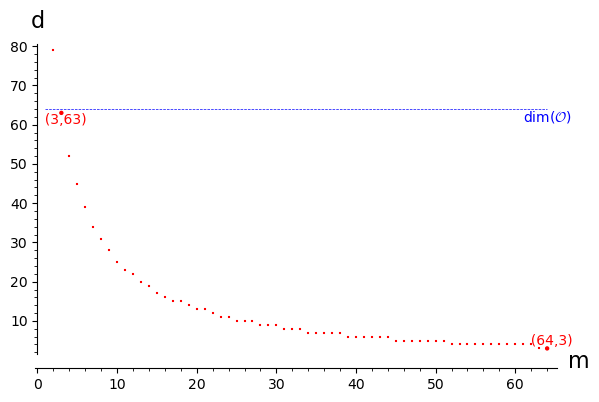

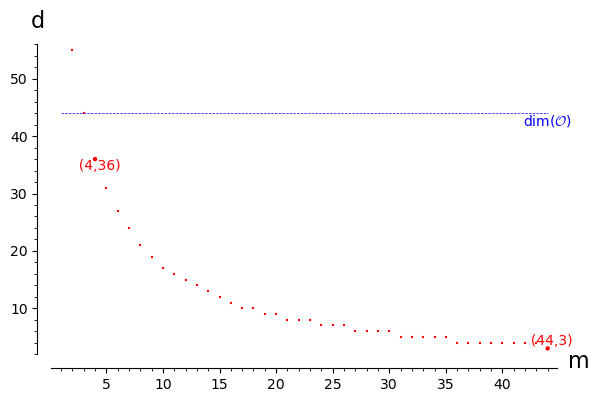

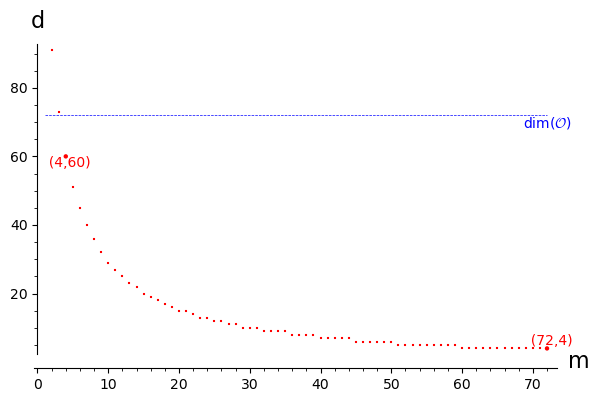

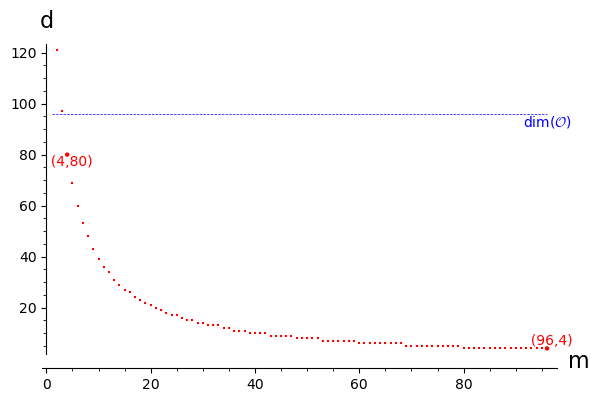

In [17]:
load('params.sage')
load('tools.sage')

def delta_dm(n,r,m) :
    """Special case of DM98, TH2.1 where vector(d) = (2,...,2)"""

    return (r+1)*(n-r) - m*binomial(2+r, r)

def delta_moins(n,m,r) :
    return min(delta_dm(n,r,m), n-2*r-m )

def borne_debarre_manivel(n,m) :
    """ 
    Return smallest r such that there are no r-dimensional proj subspaces in the projective variety spanned by m generic equations of degree two in P(K^n)
    """
    for r in range(2,n) :
        if delta_moins(n,m,r) < 0:
            return r
    return n

for name,q,n,m  in UOVparams :
    points = []

    
    for k in range(2,m+1) :

        r= 2
        
        delta = delta_dm(n-1,r-1,k)
        while delta >= 0 : ### While delta is positive, the dimension can be increased.
                           ### As soon as delta is negative, then the existence of O of dim r is not a generic property.
            r+=1 
            delta = delta_dm(n-1,r-1,k)
        r-=2
        points.append(((k,borne_debarre_manivel(n-1,k))))
    
    i_star = 0
    while points[i_star][1] > m-1 :
        i_star+=1
    
        
    p=list_plot(points, color='red', size=1, marker='+')#, ticks=(range(2,44),range(1,44)))
    
    p+= text('  (%s,%s)'%(points[-1][0],points[-1][1]),points[-1],vertical_alignment='bottom',color='red')
    p+= point(points[-1], color="red")

    p+= text('  (%s,%s)'%(points[i_star][0],points[i_star][1]),points[i_star],vertical_alignment='top',color='red')
    p+= point(points[i_star], color="red")

    p+= plot(m, (1, m), color='blue', linestyle='dashed', thickness=0.5) 
    p+= text('dim($\\mathcal{O}$)',(m,m),vertical_alignment='top',color='blue')


    p.axes_labels(['m', 'd'])
    p.show()
    


## State of the art of the Cryptanalysis of (U)OV

We provide implementations of some precomputations to the direct attack, and of the state-of-the-art key recovery attacks described in Section 3.3.
Most of these attacks are algebraic: thus, SageMath can be used to model the system efficiently, but it is usually necessary to outsource the polynomial-system-solving part of these attacks to a dedicated library (such as magma, msolve, M4GB, ...) to tackle larger instances.
This can be done in SageMath by installing optional libraries.


#### Algorithms of Kipnis-Patarin-Goubin and Thomae-Wolf.

Before describing the key recovery attacks, we detail the Kipnis-Patarin-Goubin and Thomae-Wolf algorithms, which are closely related.

We begin with the Kipnis-Patarin-Goubin algorithm, which takes as input a collection P of m polynomials of degree two in at least m(m-1) variables, and returns a linear subspace of dimension m that is isotropic for all input polynomials.

This enables one to find solutions of P(X)=t in polynomial time by solving a linear system which mimicks the UOV signing procedure.

We provide a function ROMKeyGen which generates a generic collection of quadratic polynomials, which is used to distinguish the behavior of UOV public keys from generic quadratic maps, and run the KPG algorithm on such generic instances to highlight the generality of this approach. 

In [18]:
load("UOV.sage")
load("cryptanalysis.sage")

q= 2**6
n = 16
m = 4

def ROMKeyGen(q,m,v) :
    """
    This function generates a collection of random matrices representing generic quadratic forms.
    It returns a pair (A,F), G where (A,F) are identity matrices to be consistent with the non-ROM KeyGen. 
    """
    FF = GF(q)
    n = m+v
    G = [ matrix(FF,complete_basis([], FF**(n))) for _ in range(m)]
    if (q%2) != 0 :
        for i in range(m):
            G[i] = (G[i] + G[i].transpose())
    return (matrix.identity(n), [matrix.identity(n) for _ in range(m)]), G 

_, P = ROMKeyGen(q,m,n-m)
print(f"We consider UOV paramters (n, m, q) = ({n}, {m}, {q}).")

r= m

print("We verify the KPG criteria, m(m-1) <= n-m bound:")
print(r*(m-1), "<=", n-m
     )
    
def KPG_induction(P, r, verbose=False) :
    """
    Implementation of the Kipnis, Patarin, Goubin algorithm to compute a linear subspace vanishing a collection of quadratic forms in fields of characteristic two.
    """
    n = P[0].dimensions()[0]
    m = len(P)
    FF = P[0].base_ring()

    ###Induction: step 0
    i=0
    s1 = [1] + [0 for _ in range(m-1)] + [FF.random_element() for  _ in range(n-m)]
    S1 = vector(s1)
    S = [S1]
    if verbose:
        print("The basis is iteratively computed, and S1 is chosen randomly:")
        print("S1=", S1)


    for i in range(1, m):
        ###Induction: step i
        R = PolynomialRing(FF, ['s'+str(i) for i in range(n-1)], n-1)
        si =  list(R.gens())[:i] + [1] + list(R.gens())[i:] 
        Si = vector(si)
        eqs = []
        for Sj in S :
            for p in P[:r]:
                eqs.append(Sj*p*Si + Si*p*Sj)
        I = Ideal(eqs)
        d = I.dimension()

        H = []
        j = 0
        while j < d and j < m-1 :
            H.append(R.gens()[j]) 
            j+=1
        while j < d :
            H.append(FF.random_element() + sum([FF.random_element()*x for x in R.gens()[m-1:]])) 
            j+=1        
        V = (Ideal(eqs+H).variety())[0]




        fSi = Si([V[s] for s in R.gens()])
        if verbose:
            print("S"+str(i+1)+"=", fSi)

        S.append(fSi)
    matS = matrix(FF, m,n, S)
    return matS

matS = KPG_induction(P,r, verbose = True)
print("One can verify that S is full rank.")
print(f"Rank S = {matS.rank()}.")

print()

R = PolynomialRing(GF(q), 'X', m)
X = vector(R.gens())


assert r == m # Assert that we are in the KPG context.

t = [GF(q).random_element() for _ in  range(m)]
print('We sample a random target vector:')
print(t)
print("""We have "linearized" all quadratic equations, and must solve a linear system:""")

eqs = [X*matS*p*matS.T*X for p in P]
for i in eqs:
    print(i)
vecs = []
for i in eqs :
    lin = i**(q//2)
    coeffs = [ lin.coefficient(x**q) for x in R.gens()]
    vecs.append(coeffs)
M = matrix(vecs)
t_pow = vector( [ ti**(q//2) for ti in t])
X = list(M.solve_right(t_pow))
print("If the system is invertible, we find a solution:", X)
print("We can verify it by computing P(x) - t:")
print([eqs[i](X) - t[i] for i in range(len(eqs))])

We consider UOV paramters (n, m, q) = (16, 4, 64).
We verify the KPG criteria, m(m-1) <= n-m bound:
12 <= 12
The basis is iteratively computed, and S1 is chosen randomly:
S1= (1, 0, 0, 0, z6^5 + z6^4 + z6^2 + z6, z6^2 + z6 + 1, z6^5 + z6^4, z6^5 + z6^3 + z6^2, z6^5 + z6^4 + z6, z6^5 + z6^4 + z6^3 + z6^2, 1, z6^4 + z6^3 + z6^2 + z6 + 1, z6^5 + z6^4 + z6^2 + z6 + 1, z6^3 + z6^2 + z6, z6^5 + z6^4 + z6^3 + z6 + 1, z6^5 + z6^3 + z6^2 + 1)
S2= (0, 1, 0, 0, z6^2 + 1, z6^5 + z6^4 + z6^3 + z6^2 + 1, z6^2, z6^2 + z6, z6^5 + z6^4 + z6^3 + z6^2, z6^5 + z6^2, z6^5 + z6, z6^4 + z6, z6^3 + z6^2 + z6, z6^5 + z6^4 + z6^3 + z6^2 + z6, z6^4 + z6^3 + z6^2 + z6, z6^4 + z6^3 + z6^2 + z6)
S3= (0, 0, 1, 0, z6^5 + z6^2 + z6, z6^4 + z6^3 + z6 + 1, z6^5 + 1, z6^5 + 1, z6^3 + z6^2 + z6 + 1, z6^5 + z6^4 + z6^2, z6^5 + z6^4 + z6^3 + z6^2 + 1, z6^5 + z6^3 + z6^2 + 1, z6^3, z6^4 + z6 + 1, z6^4 + z6, z6^2 + z6 + 1)
S4= (0, 0, 0, 1, z6^5 + z6^4 + z6^3 + z6 + 1, z6^5 + z6^3 + z6^2, z6^4 + z6 + 1, z6^2 + z6, 1, z6^5 + z6

Next, we present the Thomae-Wolf algorithm.
The algorithm is similar to the Kipnis-Patarin-Goubin algorithm, however it returns a linear subspace which cancels only a subset of the input polynomials.

Notice that these two algorithms have a very similar architecture, both relying on a subroutine which is the Kipnis, Patarin, Goubin inductive algorithm.
The difference is that the final solving step solves a linear system in the Kipnis, Patarin, Goubin case, and a quadratic system in the Thomae-Wolf case.


We disable the verbose option here for the sake of brevity.

In [21]:
load("UOV.sage")
load("cryptanalysis.sage")


q=2**8
n = 21
m = 5
_, P = ROMKeyGen(q,m,n-m)
print(f"We consider UOV parameters (n, m, q) = ({n}, {m}, {q}).")

r= 4
print('We set r =', r)

print("We verify the Thomae-Wolf bound:")
print(r*(m-1), "<=", n-m)
print("Note that the KPG algorithm would fail, as m(m-1) > n-m")
print(m*(m-1), ">", n-m)
 
matS = KPG_induction(P,r, verbose = False)

print("We compute S with the inductive algorithm of Kipnis, Patarin, Goubin.")
print("Dimensions of S:", matS.dimensions())
print("One can verify that S is full rank.")
print(f"Rank S = {matS.rank()}.")

print()

R = PolynomialRing(GF(q), 'X', m)
X = vector(R.gens())

assert r < m # Assert that we are in the Thomae-Wolf context.

t = [GF(q).random_element() for _ in  range(m)]
print('The target vector is:')
print(t)
print("""We have "linearized" a subset of equations, and must solve a quadratic polynomial system using a Gröbner basus algorithm instead of linear algebra.""")
eqs = [X*matS*p*matS.T*X for p in P[:r]]
sys = [X*matS*P[i]*matS.T*X - t[i] for i in range(r,m)]
for i in range(r) :
    lin = eqs[i]**(q//2)
    coeffs = [ lin.coefficient(x**q) for x in R.gens()]
    Li = sum([coeffs[j]*R.gens()[j] for j in range(m)])
    sys.append( Li-t[i]**(q//2) )
for i in sys:
    print(i)
I = Ideal(sys)
print()
print('The variety is')
print(I.variety())
print("If it is empty, we can simply restart the algorithm with a different choice of S1.")

We consider UOV parameters (n, m, q) = (21, 5, 256).
We set r = 4
We verify the Thomae-Wolf bound:
16 <= 16
Note that the KPG algorithm would fail, as m(m-1) > n-m
20 > 16
We compute S with the inductive algorithm of Kipnis, Patarin, Goubin.
Dimensions of S: (5, 21)
One can verify that S is full rank.
Rank S = 5.

The target vector is:
[z8^7 + z8^5 + z8^4 + z8, z8^4 + z8^3 + z8^2 + z8 + 1, z8^7 + z8^6 + z8^4, z8^7 + z8^6 + z8^5 + z8^2 + 1, z8^6 + z8^5 + z8^4 + z8^3 + z8^2 + z8]
We have "linearized" a subset of equations, and must solve a quadratic polynomial system using a Gröbner basus algorithm instead of linear algebra.
(z8^7 + z8^6 + z8^5 + z8^3)*X0^2 + (z8^7 + z8^6 + z8^5 + z8 + 1)*X0*X1 + (z8^6 + z8^3 + z8^2 + 1)*X1^2 + (z8^7 + z8^5 + z8^3 + z8^2)*X0*X2 + (z8^7 + z8^6 + z8^2)*X1*X2 + (z8^7 + z8^5 + z8^4 + z8^3 + z8)*X2^2 + (z8^5 + z8^3)*X0*X3 + (z8^7 + z8^2 + 1)*X1*X3 + (z8^5 + z8^4 + z8^3 + z8^2)*X2*X3 + (z8^7 + z8^6 + z8^2 + z8)*X3^2 + (z8^7 + z8^5 + 1)*X0*X4 + (z8^5 + z8^4 + z

#### Cryptanalysis of Oil and Vinegar

We demonstrate the polynomial-time attack of Kipnis and Shamir against Oil and Vinegar, and implement the optimization described in Section 3.3.4 which makes the algorithm deterministic.

The attack is very efficient, even for large parameter sets, but we use a toy instance to visually highlight the structures that are exploited.

In [22]:
load("UOV.sage")

(A,F), G = KeyGen(251, 8, 8)

S = F[0].inverse()*F[1]
M = G[0].inverse()*G[1]

print("The block structure of the secret endomorphisms highlighted by Lemma 4.6 is:")
print(S)
print()
print('The public endomorphism M does not have the same structure:')
print(M)
print()
print('But its characteristic polynomial is still a square: ')
print("chi_M(x)=",M.charpoly().factor())
r=M.charpoly().sqrt()
print('Its square root is r=', r,'. ')
print("which can sometimes be factored further, but this has no incidence on the attack, by Lemma 3.21.")
print(r.factor())
print('Compute the right kernel of the evaluation of r:')
O = (r(M)).right_kernel()
print(O)
B = O.basis_matrix()
print()
print("We verify that it is an OV secret key by applying the corresponding change of varaibles to the public key (Characterisation 3.7):")
for i in range(len(G)):
    print(B * G[i]* B.T)
    print()

The block structure of the secret endomorphisms highlighted by Lemma 4.6 is:
[151  90 137 178  48 198   3 110 170   3  84  13   1 242  18 194]
[114 121  96 128 204  28 207 220  50  83 116 162  28 246 152  44]
[122  12 202 166 232 207 171   5  64 198 133 113 178 129 196  92]
[ 90 221 202 196 196 106 194  46 110 216 175 164  30 180 156 233]
[129 103 182  48 250  51 229 141 187 208  63 233 151 246 126  70]
[117 154  50  67 249 247 177  79   1  54 236 221 154   7  18  92]
[ 53  18 159  72  36  97 149  92  74  96  95  18  49 137 223 235]
[ 89   7 113 189  45  19  14  59 236   4 134  76 130  46  28 239]
[  0   0   0   0   0   0   0   0 155 174   6 244 108  25 139 126]
[  0   0   0   0   0   0   0   0 189 154 177 157 104 152 204   4]
[  0   0   0   0   0   0   0   0  72   8  89 230  79 219 106  19]
[  0   0   0   0   0   0   0   0 236 100  95 121 210 238  47  13]
[  0   0   0   0   0   0   0   0   4 105 175  38 128 118 174  32]
[  0   0   0   0   0   0   0   0 220 114 227 112  84 168 151 234]

### State of the art of the cryptanalysis of UOV

We provide an implementation of the key recovery attacks considered in the Round 2 submission for UOV at NIST.

#### Kipnis-Shamir attack

We begin with the Kipnis-Shamir attack due to Kipnis, Patarin, Goubin, which generalizes the OV attack presented previously.

NB: The code may seem a little odd compared to the standard description of the Kipnis-Shamir attack, as we implement it following the Singular Point description of Chapter 7. 

In [24]:
load("cryptanalysis.sage")

n = 22
m = 10
q = 17
_, G = KeyGen(q,m,n-m)

def KipnisShamir(G, verbose = False) :
    """
    Perform a Kipnis-Shamir attack on G.
    This implementation follows the singular point formalism, but it is entirely equivalent to the original formulation.
    The verbose=True option artificially links our formulation to the eigenspace formulation.
    """
    o = len(G)
    n= G[0].dimensions()[0]
    v = n-o
    q = G[0].base_ring().cardinality() 
    
    def test(G,x):
        for g in G :
            if x*g*x != 0 :
                return False
        return True 

    r = o-1
    g = itertools.product(range(q),repeat=r)
    tries = 0
    if verbose:
        print(f"We expect q^(n-2m)=q^{n-2*o}=2^{float(log(q^(n-2*o),2))} tries before success.")
    print("We repeatedly choose a random linear combination of public key matrices, and compute the corresponding characteristic polynomial following Section 3.3.5.")
    for i in g :
        tries+=1
        guess =  [1] + list(i) 
        M = sum([guess[i]*G[i] for i in range(o)])
        if M.determinant() != 0:
            continue
        for x in M.kernel().basis():
            if test(G,x):
                r = (G[1].inverse()*M).charpoly()
                if verbose:
                    print(f"For instance, we choose the linear coefficients {guess} for the combination.")
                    print(f"The characteristic polynomial is {r.factor()}")
                    print("For each factor, we compute a basis of the corresponding eigenspace:")
                    print("If it is non-empty, then we have found a solution.")
                    for f,_ in r.factor() :
                        print(f,":" , f(M).right_kernel().basis())
                        try: 
                            y = (f(M).right_kernel()).basis()[0]
                            break
                        except:
                            continue
                    print(f"The number of attempts was q^{round(log(tries, q),2)}.")
                return x 
            else :
                continue
    raise Exception("Attack failed.")


try: 
    x = KipnisShamir(G, verbose=True)
except:
    print("Attack has failed.")
print(x)
print("We check that it cancels all public key polynomials:")
for g in G :
    print(x*g*x)
print("Under the KPG hypothesis (See Chapter 7), this implies that x is in the oil space.")
print("This heuristic is proven to hold for Zariski-generic UOV keys in Chapter 5, \nand we can also replace it with a deterministic decision algorithm introduced in Chapter 6.")

We expect q^(n-2m)=q^2=2^8.174925682500678 tries before success.
We repeatedly choose a random linear combination of public key matrices, and compute the corresponding characteristic polynomial following Section 3.3.5.
For instance, we choose the linear coefficients [1, 0, 0, 0, 0, 0, 1, 1, 14, 2] for the combination.
The characteristic polynomial is (x + 11) * x^3 * (x^4 + 9*x^3 + 9*x^2 + 11*x + 2) * (x^14 + 5*x^13 + 10*x^12 + 16*x^10 + 6*x^9 + 7*x^8 + x^7 + 15*x^6 + x^5 + 11*x^4 + 6*x^3 + 10*x^2 + 3*x + 9)
For each factor, we compute a basis of the corresponding eigenspace:
If it is non-empty, then we have found a solution.
x + 11 : [

]
x : [
(1, 6, 12, 12, 2, 6, 1, 6, 4, 0, 11, 1, 1, 12, 9, 0, 13, 11, 15, 6, 5, 6)
]
The number of attempts was q^3.04.
(1, 6, 12, 12, 2, 6, 1, 6, 4, 0, 11, 1, 1, 12, 9, 0, 13, 11, 15, 6, 5, 6)
We check that it cancels all public key polynomials:
0
0
0
0
0
0
0
0
0
0
Under the KPG hypothesis (See Chapter 7), this implies that x is in the oil space.
This 

#### Reconciliation Attack

Next, we provide a description of the Reconciliation attack, which is instanciated using the Debarre and Manivel bound. The Reconciliation attack was introduced by Ding, Yang, Chen, Chen, Cheng.

Here, we follow Beullens' description of the attack which simultaneously computes r vectors in O.
Then, an iterative method is used to compute the remaining o-r vectors required to form a basis of O in polynomial time. Note that the complexity of the first step is exponential and grows very quickly with r, therefore it is only feasible to test it using very small instances with the native SageMath solver.

We show in Proposition 3.24 that r can be chosen using the Debarre and Manivel bound (Theorem 3.9).


In [26]:
load("tools.sage")
load("cryptanalysis.sage")

n = 7
m = 3
q = 31
_, G = KeyGen(q,m,n-m)
r = 2
print(f"We consider UOV{n,m,m,q} with r={r}.")
print("We verify that the choice of parameters enables the attack to succeed by Proposition 3.24.")
print(f"We require that delta(n-1,r,m-1)<r(m-r), i.e. {delta_dm(n-1,m-1,r)}<{r*(m-r)}.")
assert delta_dm(n-1,m-1,r)<r*(m-r)

print() 


def reconciliation(G, r, verbose=False) :
    """
    Given m matrices G1...Gm, find, if it exists, a (basis of a) linear subspace A of dimension m such that A.T G1 A = ... = A.T Gr A = (0)^m*m. 
    The algorithm begins by computing r vectors of A simultaneously, before completing the basis using linear algebra.
    """
    #
    F = G[0].base_ring()
    n = G[0].dimensions()[0]
    m = len(G)
    d=m
    id_block = identity_matrix(F, d)[:r,:]
    
    # Non-linear step.
    R = PolynomialRing(F, 'x', r*(n-m))
    M = matrix(r,n-m,R.gens())
    
    X = block_matrix(R, 1, 2, [id_block, M])
    if verbose:
        print("We define an indeterminate sub-basis of the oil space.")
        print(X)
        print("The polynomial system is then the entries of the matrices X^T.Pi.X for 1 <= i <=m.")
    eqs = []
    for g in G:
        eqs = eqs + (X*g*X.T).coefficients()

    codim = m*binomial(r+1,2)
    if verbose:
        print(f"The system has codimension {codim} and {r*(n-m)} variables.")
        if codim > r*(n-m) :
            print(f"By the existence of a UOV trapdoor, we know that it admits a solution.")
    return eqs, X


eqs, X = reconciliation(G,r, verbose = True)
I = Ideal(eqs)
V = I.variety()[0] 
print("We obtain the variety")
print(V)
print('We deduce the following sub-basis:')
B1 = X([V[x] for x in X[0,0].parent().gens()])
print(B1)

print(f"We must compute {m-r} additionnal vector(s) to obtain a full basis of the oil space.")

id_block = identity_matrix(GF(q), m)[r:,:]
R = PolynomialRing(GF(q), 'x', (m-r)*(n-m))
M = matrix(m-r,n-m,R.gens())
Y = block_matrix(R, 1, 2, [id_block, M])

print("This computation is significantly cheaper thanks to the linear polynomials induced by the cross terms X.T P Y.")
eqs = []
for g in G:
    eqs = eqs + (Y*g*Y.T).coefficients() + (B1*g*Y.T).coefficients() 
J = Ideal(eqs)
print("We obtain the values of the last vectors:")
W = J.variety()[0]
print(W)
B2 = Y([W[x] for x in R.gens()])

print("Thus, the full basis is ")
B = block_matrix(GF(q), 2,1,[B1,B2])
print(B)
print("We verify this using the isotropic subspace characterisation:")
for g in G :
    print(B * g* B.T)
    print()

We consider UOV(7, 3, 3, 31) with r=2.
We verify that the choice of parameters enables the attack to succeed by Proposition 3.24.
We require that delta(n-1,r,m-1)<r(m-r), i.e. 0<2.

We define an indeterminate sub-basis of the oil space.
[ 1  0  0|x0 x1 x2 x3]
[ 0  1  0|x4 x5 x6 x7]
The polynomial system is then the entries of the matrices X^T.Pi.X for 1 <= i <=m.
The system has codimension 9 and 8 variables.
By the existence of a UOV trapdoor, we know that it admits a solution.
We obtain the variety
{x7: 4, x6: 12, x5: 11, x4: 25, x3: 20, x2: 22, x1: 18, x0: 29}
We deduce the following sub-basis:
[ 1  0  0 29 18 22 20]
[ 0  1  0 25 11 12  4]
We must compute 1 additionnal vector(s) to obtain a full basis of the oil space.
This computation is significantly cheaper thanks to the linear polynomials induced by the cross terms X.T P Y.
We obtain the values of the last vectors:
{x3: 15, x2: 25, x1: 20, x0: 10}
Thus, the full basis is 
[ 1  0  0 29 18 22 20]
[ 0  1  0 25 11 12  4]
[-----------

We show that the attack fails if the value of r is too small. 
If r is too small, then the subspace computed by the first step of the attack is generic in the Debarre and Manivel sense, and thus with overwhelming probability it is in general position with the oil space, thus the second step (the linear reconstruction) fails.

In [78]:
load("tools.sage")
load("cryptanalysis.sage")

n = 7
m = 3
q = 31
_, G = KeyGen(q,m,n-m)
r = 1
print(f"We consider UOV{n,m,m,q} with r={r}.")
print(f"This time, delta(n-1,r,m-1)>r(m-r), i.e. {delta_dm(n-1,m-1,r)}>{r*(m-r)}.")

print() 

eqs, X = reconciliation(G,r, verbose = True)
I = Ideal(eqs)
dim = I.dimension()
print(f"The dimension of the variety is {dim} which is positive, therefore we must add generic linear polynomials to reach dimension 0.")
H = [sum( GF(q).random_element()*x for x in X.coefficients()) for _ in range(dim)]
I2 = Ideal(eqs+H)
print(f"We can verify that the dimension of the ideal is now zero : dim I={I2.dimension()}, but since we are now in a generic case there is no guarantee that there exist rational solutions.")
V = I2.variety()[0] 
print("We obtain the variety")
print(V)
print('We deduce the following sub-basis:')
B1 = X([V[x] for x in X[0,0].parent().gens()])
print(B1)

print(f"We must compute {m-r} additionnal vectors to obtain a full basis of an oil space.")

id_block = identity_matrix(GF(q), m)[r:,:]
R = PolynomialRing(GF(q), 'x', (m-r)*(n-m))
M = matrix(m-r,n-m,R.gens())
Y = block_matrix(R, 1, 2, [id_block, M])

eqs = []
for g in G:
    eqs = eqs + (Y*g*Y.T).coefficients() + (B1*g*Y.T).coefficients() 
J = Ideal(eqs)
print("Even if we were lucky enough to find a rational solution at the previous step, the next polynomial system has no solutions with overwhelming probability.")
print(f"We verify this using sage: dim(J)={J.dimension()}.")

We consider UOV(7, 3, 3, 31) with r=1.
This time, delta(n-1,r,m-1)>r(m-r), i.e. 6>2.

We define an indeterminate sub-basis of the oil space.
[ 1  0  0|x0 x1 x2 x3]
The polynomial system is then the entries of the matrices X^T.Pi.X for 1 <= i <=m.
The system has codimension 3 and 4 variables.
The dimension of the variety is 1 which is positive, therefore we must add generic linear polynomials to reach dimension 0.
We can verify that the dimension of the ideal is now zero : dim I=0, but since we are now in a generic case there is no guarantee that there exist rational solutions.
We obtain the variety
{x3: 26, x2: 12, x1: 29, x0: 4}
We deduce the following sub-basis:
[ 1  0  0  4 29 12 26]
We must compute 2 additionnal vectors to obtain a full basis of an oil space.
Even if we were lucky enough to find a rational solution at the previous step, the next polynomial system has no solutions with overwhelming probability.
We verify this using sage: dim(J)=-1.


#### Intersection Attack

The Intersection attack was introduced by Beullens.
It is an algebraic attack that combines the observations made in the design of the Kipnis-Shamir attack with the framework of the Reconciliation attack.
The polynomial system models the existence of a vector in the intersection of the image of O by two or more linear transformations. 

As a consequence, the attack computes (at least) two vectors of O simultaneously, which implies that the Reconciliation steps to construct a full basis from the solutions of this attack is very cheap.


In [32]:
load("cryptanalysis.sage")

n = 12
m = 5
q = 31
_, G = KeyGen(q,m,n-m)
while G[0].determinant() == 0 or G[1].determinant() == 0 :
    _, G = KeyGen(q,m,n-m) #Ensure that the matrices are invertible, this is not a strong requirement.

    
k = 2
print(f"We consider UOV{n,m,m,q} with k={k} intersections.")
print(f"Indeed, the criterion of Beullens n<o(2k-1)/(k-1) holds: {n} < {m*(2*k-1)/(k-1)},")

def intersection(G, o, ind = (0,1), verbose = False) :
    """ 
    Takes as input a UOV public key and returns the polynomial system modelling the intersection attack with k = 2 of Beullens.
    """

    i1, i2 = ind
    m = len(G)
    n = G[0].dimensions()[0]
    F = G[0].base_ring()
    R = PolynomialRing(F,'X',2*n-3*o) #Variable count from Beullens' criterion.
    x = vector([1] + [0 for _ in range(3*o-n-1)] + list(R.gens()))
    
    sys = []

    polar_forms = [g + g.T for g in G] #This is important in characteristic two and has no consequence in even characteristic.
    M1 = polar_forms[i1].inverse()
    M2 = polar_forms[i2].inverse()
    
    Mix = M1*x 
    Mjx = M2*x 
  
    if verbose :
        print("We consider an indeterminate vector X in the intersection of P1*O and P2*O.")
        print(x)
        print("The following two vectors, its pre-images by P1 and P2, are elements of O:")
        print(f"P1.inverse()X = {Mix}")
        print()
        print(f"P2.inverse()X = {Mjx}")
        print("Thus, we use the Reconciliation attack to model that property.")
        
    for e in range(len(G)) :
        Ge=  G[e]
        if e != i1 : # We avoid adding useless equations, note though that they do not slow down a solver if kept.
            sys.append(Mix *Ge*Mix)
        sys.append( Mix *Ge*Mjx )
        if e != i2 :
            sys.append(Mjx *Ge*Mjx)
    return sys, x

sys, x = intersection(G, m, verbose = True)

print("We obtain the following solution:")

I = Ideal(sys)
V = I.variety()[0]
X = x([V[var] for var in x[-1].parent().gens()])
print("X =",X)
print()
print("We are not done yet, this is not an element of O!")
print("This is the image by P1, P2 of an element of O.")
print("The solutions are P1.inverse()*X, P2.inverse()*X:")
o1 = G[0].inverse()*X
o2 = G[1].inverse()*X
print(o1, "and", o2)
print()
print("We perform the full reconciliation using these two vectors.")
print(f"We must compute {m-k} additionnal vectors to obtain a full basis of the oil space.")
B1 = matrix([o1,o2]) 

id_block = identity_matrix(GF(q), m)[k:,:]
R = PolynomialRing(GF(q), 'x', (m-k)*(n-m))
M = matrix(m-k,n-m,R.gens())
Y = block_matrix(R, 1, 2, [id_block, M])

eqs = []
for g in G:
    eqs = eqs + (Y*g*Y.T).coefficients() + (B1*g*Y.T).coefficients() 
J = Ideal(eqs)
print("We obtain the values of the last vectors:")
W = J.variety()[0]
print(W)
B2 = Y([W[x] for x in R.gens()])

print("Thus, the full basis is ")
B = block_matrix(GF(q), 2,1,[B1,B2])
print(B)
print(f"Which is inded of rank {B.rank()}.")
print("We verify this using the isotropic subspace characterisation:")
for g in G :
    print(B * g* B.T)
    print()


We consider UOV(12, 5, 5, 31) with k=2 intersections.
Indeed, the criterion of Beullens n<o(2k-1)/(k-1) holds: 12 < 15,
We consider an indeterminate vector X in the intersection of P1*O and P2*O.
(1, 0, 0, X0, X1, X2, X3, X4, X5, X6, X7, X8)
The following two vectors, its pre-images by P1 and P2, are elements of O:
P1.inverse()X = (3*X0 - 10*X1 + 13*X2 + 2*X3 - 7*X4 + 10*X5 + 13*X6 - 10*X7 + 3*X8 + 10, -2*X0 + 10*X1 - 13*X2 - 9*X3 - 11*X4 - 9*X5 + 15*X6 + 13*X7 + 13, 2*X0 - 12*X1 - 7*X2 + 10*X3 + 9*X4 - 10*X5 - 2*X6 - 14*X7 + X8 - 4, -4*X0 - 12*X1 - X2 + 13*X3 + X5 + 3*X6 + 15*X7 - 7*X8 + 3, -12*X0 + 6*X1 - 8*X2 - X3 + 15*X4 - 12*X5 - 9*X6 + 13*X7 - 9*X8 - 10, -X0 - 8*X1 - 8*X2 + 14*X3 - 15*X4 - 10*X5 - 7*X6 - 5*X7 + 12*X8 + 13, 13*X0 - X1 + 14*X2 - 13*X3 + 3*X4 - 11*X5 + 5*X6 - 15*X7 - 9*X8 + 2, 15*X1 - 15*X2 + 3*X3 - 2*X4 - 3*X5 - 4*X6 - 6*X7 + 10*X8 - 7, X0 - 12*X1 - 10*X2 - 11*X3 - 3*X4 + 4*X5 - 14*X6 - 2*X7 - 6*X8 + 10, 3*X0 - 9*X1 - 7*X2 + 5*X3 - 4*X4 - 14*X5 + 14*X6 - 12*X7 + 5*

### Bit cost computations in NIST methodology

We conclude this section with some tools replicating the method used in NIST submission material to estimate the practical complexity of various attacks against UOV and its variants to define parameter sets.

In [88]:
load("params.sage")

### Cost of an arithmetic operation in gates
def gates(q):
    """
    Return the cost of one multiplication in Fq in gates following NIST methodology.
    """
    return log(3*2*(log(q, 2)**2 + log(q,2)),2)

### Degree of regularity of semi-regular polynomial sequences
def dreg_semi_reg(n,m) :
    """ 
    HS of a semi-regular quadratic system m eqs in n variables.   
    """
    R.<t> = PowerSeriesRing(ZZ, default_prec=m+1)
    h = (1-t^2)^(m)/(1-t)^(n+1) ### +1 ?
    #print(h)
    L = list(h)
    for i in range(len(L)) :
        if L[i] <= 0 :
            return i
    return len(L)+1

def cost_semi_reg(n,m,q) :
    """
    Compute the bit cost of solving a semi regular system of n variables m equations in Fq assuming "sparse solver" using a hybrid algorithm over Fq.
    """
    d = dreg_semi_reg(n,m)
    
    mini= float(log(binomial(n + d, d)**2 * binomial(n, 2),2))
    k_min = 0
    
    for k in range(1,10) :
        d = dreg_semi_reg(n-k,m)
        
        temp = float(log(q^k * binomial(n-k + d, d)**2 * binomial(n-k, 2),2))
        if temp < mini :
            mini = temp 
            k_min = k
        if k_min > 0 and temp > mini:
            break
    return mini , k_min

###Direct attack
def thomae_wolf(n,m):
    """
    Return k such that a solution of a quadratic system in m eqs and n vars can be found by solving a systme in m-k eqs and vars.
    """
    r = 0
    while r*(m-1) <= n-m :
        r+=1
    return r-1

def cost_direct(n,m,q):
    """
    Cost of forging a signature of an MQ system over Fq in n vars and m eqs.
    """
    r = 0
    if q % 2 :
        if n > 2*m +2 :
            r=1 # Chap 10
    else :
        r = thomae_wolf(n,m)
    cost, k = cost_semi_reg(m-r,m-r,q)
    return cost, r, k

### Kipnis Shamir
def cost_ks(n,m,q) :
    """ 
    Cost of the Kipnis-Shamir attack against UOV(n,m,q)
    """
    return float(log(q^(n-2*m)*n^2.81, 2))

### Intersection 
def cost_inter(n,m,q):
    k = 2
    """while (n < (2*k-1)/(k-1)*m) and (k<=m) :
        k+=1
    k-=1
    """
    N_vars =  n*k - (2*k-1 )*m
    M_eqs = binomial(k+1,2)*m - 2*binomial(k,2)
    cost, i = cost_semi_reg(N_vars,M_eqs,q)
    return cost, i, k


UOVparams = [
["UOV-Is", 16, 160, 64],
["UOV-Ip", 256, 112, 44],
["UOV-III", 256, 184, 72],
["UOV-V", 256, 244, 96]
]



print("We consider UOV parameters of the Round 2 NIST submission.")
print("For each parameter set, we indicate the log2  of the expected bit cost of each attack using NIST methodology.")
print("In the relevant cases, we indicate the parameters of the attacks.")
print("The threshold bit complexities are 2^143, 2^207, 2^272 gates for security level I, III, V respectively.")
print()
for name, q, n, m in UOVparams:
    print(name, q, n, m)
    g = round(float(gates(q)),2)
    
    #Direct
    direct, r, k = cost_direct(n,m,q)
    direct = round(direct,2)
    print(f"Direct attack requires 2^{direct+g} gates with Thomae-Wolf r={r} and hybrid depth {k}.")
    #KS
    ks = round(cost_ks(n,m,q) + g,2)
    print(f"Kipnis-Shamir attack requires 2^{float(ks)} gates.")
    inter, k, k_inter = cost_inter(n,m,q)
    inter = round(inter,2)
    print(f"Intersection attack requires 2^{inter+g} gates with k={k_inter} and with hybrid depth {k}.")
    print()


We consider UOV parameters of the Round 2 NIST submission.
For each parameter set, we indicate the log2  of the expected bit cost of each attack using NIST methodology.
In the relevant cases, we indicate the parameters of the attacks.
The threshold bit complexities are 2^143, 2^207, 2^272 gates for security level I, III, V respectively.

UOV-Is 16 160 64
Direct attack requires 2^167.68 gates with Thomae-Wolf r=1 and hybrid depth 9.
Kipnis-Shamir attack requires 2^155.48 gates.
Intersection attack requires 2^204.19 gates with k=2 and with hybrid depth 0.

UOV-Ip 256 112 44
Direct attack requires 2^145.53 gates with Thomae-Wolf r=1 and hybrid depth 2.
Kipnis-Shamir attack requires 2^219.88 gates.
Intersection attack requires 2^165.71 gates with k=2 and with hybrid depth 0.

UOV-III 256 184 72
Direct attack requires 2^217.94 gates with Thomae-Wolf r=1 and hybrid depth 4.
Kipnis-Shamir attack requires 2^349.89 gates.
Intersection attack requires 2^249.98 gates with k=2 and with hybrid dept

### Setting the parameters

More generally, these tools enable one to optimize parameters (n, m, q) to minimize signature and key size while maintaining a given security level.


We set the values of m and q, and optimize n.


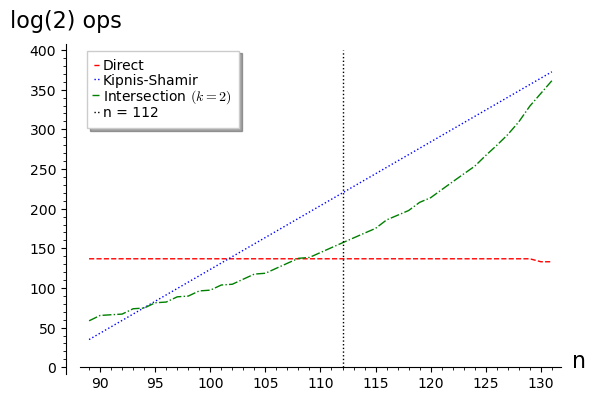

In [89]:
print("We set the values of m and q, and optimize n.")
m = 44
q = 256
X = range(2*m+1, 3*m)

listDirect = []
listKS = []
listInter = []
for n in X: 
    direct, r, k = cost_direct(n,m,q)
    listDirect.append(direct)
    
    ks = cost_ks(n,m,q) + g
    listKS.append(ks)

    inter, k, k_inter = cost_inter(n,m,q)
    listInter.append(inter)



ymin = 0
ymax =  400
# Use line() to connect points
p  = line(list(zip(X, listDirect)), color='red',linestyle='--', legend_label='Direct')
p += line(list(zip(X, listKS)), color='blue', linestyle='dotted', legend_label='Kipnis-Shamir')
p += line(list(zip(X, listInter)), color='green', linestyle='dashdot', legend_label='Intersection $(k=2)$')
p += line([(112, ymin), (112, ymax)], color='black', linestyle=':', legend_label='n = 112')
p.axes_labels(['n', 'log(2) ops'])
p.show() 

# Part 3. Contributions

We provide code implementing the algorithms described in our contributions, and both artefacts and code to replicate our experiments. For conciseness, the artefacts (typically logs of Gröbner basis solvers) are in linked GitHub repositories which are related to a given publication.

## Chapter 5. Genericity results on UOV

The goal of this chapter is to highlight and ideally prove the genericity of various regularity assumptions that are used in the analysis of algebraic attacks against UOV and its variants.

### A few random UOV polynomial systems 

We begin with a few empyrical examples which motivate these assumptions.


In [36]:
load("UOV.sage")
n = 10
m = 4
q = 31
(A,F), G = KeyGen(q, m, n-m)

R = PolynomialRing(GF(q), "X", n)
X = vector(R.gens())
P = [X*g*X for g in G]
I = Ideal(P)
var('t')
print("The (arguably) most important property of UOV public keys is that they generically form regular sequences, \nsuch that in particular the variety has the expected dimension n-m.")
print("We verify this by computing the Hilbert series of R/I, and compare it with (1-t^2)^m/(1-t)^n:")
print(f"H_R/I(t) = {factor(I.hilbert_series())}, (1-t^2)^m/(1-t)^n={((1+t)*(1-t))^m*(1-t)^(-n)}.")
print('')
print("Another interesting fact is that generically, the singular locus of the public key variety is a subset of the secret subspace.")
print(f"We verify this by computing a Gröbner basis with respect to a graded ordering. \nNotice that it contains {n-m} linear polynomials characterizing the Oil space:")
sys = P + jacobian(P,X).minors(m) + [R.gens()[0] - 1] #We must dehomogeneize since we are interested in projective singularities.
J = Ideal(sys)
gb = J.groebner_basis()
for i in range(1,n-m+1) :
    print(gb[-i])
print("This implies that the singular locus is a subspace of the Oil space.")

The (arguably) most important property of UOV public keys is that they generically form regular sequences, 
such that in particular the variety has the expected dimension n-m.
We verify this by computing the Hilbert series of R/I, and compare it with (1-t^2)^m/(1-t)^n:
H_R/I(t) = (t - 1)^-6 * (t + 1)^4, (1-t^2)^m/(1-t)^n=(t + 1)^4/(t - 1)^6.

Another interesting fact is that generically, the singular locus of the public key variety is a subset of the secret subspace.
We verify this by computing a Gröbner basis with respect to a graded ordering. 
Notice that it contains 6 linear polynomials characterizing the Oil space:
X6 - 10*X7 - 5*X8 + 9*X9 - 3
X5 - 15*X7 + 13*X8 + 3*X9 - 11
X4 - 8*X7 + 4*X8 + 9*X9 + 7
X3 + 15*X7 - 11*X8 + X9 + 4
X2 - 14*X7 + 8*X8 - 14*X9 - 13
X1 + 7*X7 + 6*X8 - 4*X9 - 2
This implies that the singular locus is a subspace of the Oil space.


### Experiments on random UOV keys


In this section, we focus on the experiments concerning generic determinantal ideals of UOV varieties and their interaction with the secret subspace. The experiments concerning the singular locus are a special case (r=1).

We comment several parameter sets to keep the notebook efficient, but if you are patient, or if you have installed optionnal solver libraries, these values are easily tested.

In [37]:
load('UOV.sage')
load('tools.sage')
### Define a collection of primes to test.

primes =  [31, 251, 1021, 4093]

### Define families of UOV parameters with different expected dimension of the singular locus, and of various rank defects.

parameters = [
    #n, m, o. In all cases, n > 2o.
    [10, 4, 4], #Regular UOV               ; r=1 dim 1
    [10, 5, 4], #Regular UOV               ; r=1 dim 1
    [10, 6, 4], #O has the same dim as V   ; r=1 dim 3 
    #[10, 8, 4],  #Non-regular variety      ; r=1 dim 5, r=2 dim 4, r=3 dim 1
    #[10, 10, 4], #Non-regular variety      ; r=1 dim 7, r=2 dim 8, r=3 dim 7, r=4 dim 4
]
print("We consider a collection of toy parameter sets for UOV and report the dimension of several determinantal ideals related to such keys for various finite fields.")
print("The experimental results presented in the thesis iterate this experiment 1000 times per prime number.")
for n,m,o in parameters:
    print(f"Parameter set (n,m,o) {n,m,o}")
    keys = []
    for p in primes : 
        _, G = KeyGen(p,o,n-o, m)
        keys.append([G,p])
    r = min(1, n-o)
    delta = r*(m - r) + o - r*(n - o)
    while delta > 0 and r <= min(n-o, m):
        print("rank defect:",r, "dimension", delta)
        
        for G,p in keys:
            vars_X = ['X'+str(i) for i in range(n)]
            vars_Y = ['Y'+str(i) for i in range((m-r)*r)]
            variables = vars_X + vars_Y
            R = PolynomialRing(GF(p), variables, n + (m-r)*r)
            X = vector(R.gens()[:n])
            Y = block_matrix(R, 1, 2, [
                matrix.identity(r), matrix(R, r, m-r, R.gens()[n:])
            ])

            eqs = [X*g*X for g in G]
            J = matrix([(g+g.T)*X for g in G])
            H = [GF(p).random_element() + sum([GF(p).random_element()*xi for xi in X]) for _ in range(delta)]
            
            sys = eqs + (Y*J).coefficients() + H
            I = Ideal(sys)
            print("Prime:", p)
            print("Singular locus has dimension delta?",I.dimension()==0)
        
        r+=1
        delta = r*(m - r) + o - r*(n - o)
    print( )
    


We consider a collection of toy parameter sets for UOV and report the dimension of several determinantal ideals related to such keys for various finite fields.
The experimental results presented in the thesis iterate this experiment 1000 times per prime number.
Parameter set (n,m,o) (10, 4, 4)
rank defect: 1 dimension 1
Prime: 31
Singular locus has dimension delta? True
Prime: 251
Singular locus has dimension delta? True
Prime: 1021
Singular locus has dimension delta? True
Prime: 4093
Singular locus has dimension delta? True

Parameter set (n,m,o) (10, 5, 4)
rank defect: 1 dimension 2
Prime: 31
Singular locus has dimension delta? True
Prime: 251
Singular locus has dimension delta? True
Prime: 1021
Singular locus has dimension delta? True
Prime: 4093
Singular locus has dimension delta? True

Parameter set (n,m,o) (10, 6, 4)
rank defect: 1 dimension 3
Prime: 31
Singular locus has dimension delta? True
Prime: 251
Singular locus has dimension delta? True
Prime: 1021
Singular locus has dime

## Chapter 6. Tangent spaces of UOV

In this chapter, we notice that the tangent space to the UOV variety at a point of O contains the entire subspace.
This observation enables an efficient reconstruction of the secret key from one secret vector, a task that runs in exponential time with the Reconciliation attack.

Recall that the main observation enabling the attack is that a linear subspace included in a variety is tangent to the variety at any of its points. 

We illustrate this with a matplotlib figure used in the slides of the defense.

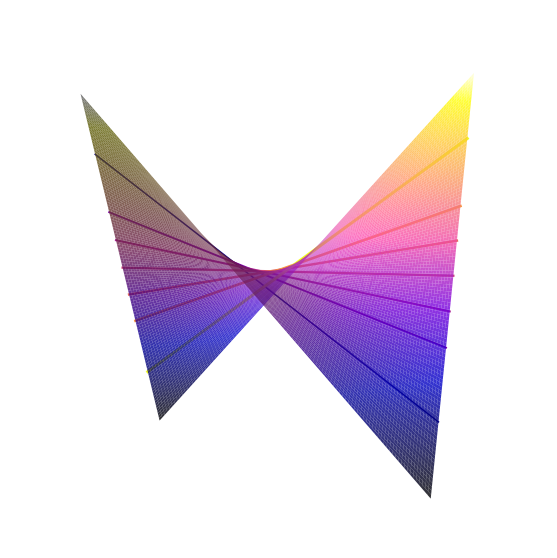

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm


# Surface
x = np.linspace(-3, 3, 120)
y = np.linspace(-3, 3, 120)
X, Y = np.meshgrid(x, y)
Z = X * Y 

color_map = cm.gnuplot2
norm = (Z - Z.min()) / (Z.max() - Z.min())
surface_colors = color_map(norm)

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, facecolors=surface_colors, rstride=1, cstride=1, alpha=0.8, linewidth=0)

# Rules
a_values = [-2, -1, -0.5, 0, 0.5, 1, 2]
t = np.linspace(-3,3, 200)
line_cmap = cm.plasma
a_norm = (np.array(a_values) - min(a_values)) / (max(a_values) - min(a_values))
for a, na in zip(a_values, a_norm):
    x_line = t
    y_line = np.full_like(t, a)
    z_line = a * t

    ax.plot3D(x_line, y_line, z_line,color=line_cmap(na),linewidth = 1.5 + 1.5 * na)

ax.view_init(elev=8, azim=280)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.set_xlim(-3,3)
ax.set_ylim(-3,3)
ax.set_zlim(-6,6)
ax.grid(False)
ax.set_axis_off()
plt.show()

Next, we demonstrate our code on UOV parameters from the Round 2 submission document.
The long part of this code is actually the key generation, the implementation of linear algebra in SageMath makes the attack efficient, and we refer to the tables in the thesis for some benchmarks.


This code is also available in its own GitHub repository: https://github.com/pi-r2/OneVector.

Fun fact, it turns out that this code unvoluntarily crashed part of a ctf challenge: https://affine.group/writeup/2023-07-CorCTF-OilSpill.

In [56]:
load("UOV.sage")

def key_recovery_from_one_vector(G,v) :
    """ 
    This function is the one that completes the attack.

    Given G a set of m quadratic forms admitting a common totally isotropic subspace O
    of dimension at least (n-m)/2, and v in O, find a basis of O as a whole.
    """
    m = len(G) 
    J = matrix([v*g for g in G]) 
    B = matrix(J.right_kernel().basis())
    B2 = []
    charac = G[0].base_ring().characteristic()
    for g in G :
        ghat = B*g*B.transpose()  #restriction of G to the kernel of J
       	if charac == 2 :
            ghat = ghat + ghat.transpose()
        for b in ghat.kernel().basis() :
            if len(B2) == 0 or b not in span(B2) :
                B2.append(b)
        if len(B2) == m :
            break
    B3 = matrix(B2)
        
    C = B3*B
    return C
    
def in_secret_subspace(G, v) :
    """
    This function takes as input a vector x and a UOV public key G, and returns True if the vector belongs to the secret subspace,
    and False otherwise. 
    """
    n = G[0].dimensions()[0]
    m = len(G)
    charac = G[0].base_ring().characteristic()

    for g in G : #Sanity check
        if v*g*v != 0 :
            return False
    
    J = matrix([v*g for g in G]) 
    B = matrix(J.right_kernel().basis())
    
    for g in G :
        ghat = B*g*B.transpose() #Restriction to K(v)
        if charac == 2 :
            ghat = ghat + ghat.transpose()
        if ghat.rank() > 2*(n-2*m) :
            return False 
    return True 
 
def oracle(A,o): 
    """Given a secret map A and the dimension of O, return a random vector of O."""
    return span(A.inverse().columns()[:o]).random_element()
    
 
q,m,v= 256, 44, 68

print(f'Parameters : (q, m, n) = {q , m, m+v}.')
print('Run the Key Generation.')
(A,F), G = KeyGen(q, m, v)
print('Next, query the oracle for a vector in O.')
v = oracle(A,m)
print("Run the attack by computing the tangent space at the given point.")
B = key_recovery_from_one_vector(G,v)
print(f'Dimension of the subspace we found is {B.dimensions()[0]}, while the dimension of O is {m}.')
print('Indeed, when we restrict the matrices to O, we find the zero matrices (Characterisation 3.7):')
print("We only show 4 matrices out of 44, but this should convince you based on the Debarre and Manivel theorem.")
for g in G[:4] :
    print(B*g*B.transpose())
    print()
print("Next, we sample 10 elements of the UOV variety, and in each case either pick a generic point of the variety or an element of O.")
print("We show that the in_secret_subspace algorithm distinguishes these two cases perfectly: ")
for i in range(10) :
    coinflip = GF(2).random_element()
    if coinflip:
        candidate = oracle(A,m)
    else:
        candidate = Sign((A,F), vector([0 for _ in range(m)]))
    val = in_secret_subspace(G, candidate)
    print(f"The tests yields {val}, and the answer is {bool(coinflip)}.")




Parameters : (q, m, n) = (256, 44, 112).
Run the Key Generation.
Next, query the oracle for a vector in O.
Run the attack by computing the tangent space at the given point.
Dimension of the subspace we found is 44, while the dimension of O is 44.
Indeed, when we restrict the matrices to O, we find the zero matrices (Characterisation 3.7):
We only show 4 matrices out of 44, but this should convince you based on the Debarre and Manivel theorem.
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 

The tests yields True, and the answer is True.
The tests yields False, and the answer is False.
The tests yields False, and the answer is False.
The tests yields True, and the answer is True.
The tests yields False, and the answer is False.
The tests yields False, and the answer is False.
The tests yields True, and the answer is True.
The tests yields True, and the answer is True.
The tests yields False, and the answer is False.


### ``x in O?`` for VOX and UOV hat plus.

In this section, we implement the attack which generalizes the previous tangent space algorithm to UOV hat plus.
We demonstrate its efficiency by targeting the parameter sets from the NIST Round 1 submission document of VOX, which is a special case of UOV hat plus.

With a dedicated polynomial system library, in our case msolve, all security levels are solved in less than 15 seconds.
The default SageMath solver will require ~10 minutes on my laptop to complete the computations for level 5, thus by default the notebook runs the level I parameters.

This algorithm is a key part of the singular point attack on VOX introduced in the next Chapter.

In [57]:
import itertools   
load("tools.sage") #I/O 
load("UOV.sage")   #KeyGen for VOX and UOV
load("VOX.sage")


def one_vector_FOX(G,x,t, verbose = False) :
    """ 
    Perform a key recovery on FOX from one known vector in the secret UOV subspace, using an enumerative approach.
    Public key G, vector x, hp parameter t.
    Return [] if the attack failed. This is also a membership test for x in O. 
    """
    n = G[0].dimensions()[0]
    o = len(G)
    v = n-o
    c = v-o
    q = G[0].base_ring().cardinality()
    if verbose: 
        print("First, we compute the right kernel of the Jacobian of the system at x.")
    J = matrix([x*g for g in G]) #This is (1/2) the Jacobian of the public key evaluated at x.
    C=matrix(J.right_kernel().basis()) #This is the change of variables that restricts to the kernel of the Jacobian.
    if verbose :
        print(f"Then, we restrict the public key equations to this subspace, which has dimension {C.dimensions()[0]}.")
    G3 = [C*g*C.transpose() for g in G] #This is the restriction of the public key to the kernel of J.

    N = G3[0].dimensions()[0]
    R = PolynomialRing(GF(q), 'X', N-1)
    X = vector(list(R.gens())+[1]) # we arbitrarily choose to set one of the hyperplanes to xN=1 which dehomogenizes the equations.
    if verbose:
        print(f"Next, we compute a grevlex Grobner basis for the ideal defined by the equations of this restriction to which we add o-2t-1={o-2*t-1} hyperplanes to obtain a zero-dimensional intersection with Ot.")
    eqs = [X*g*X for g in G3]+[X*vector([GF(q).random_element() for _ in range(N)]) for _ in range(o-2*t-1)] #Here we add 1 less hyperplane to compensate for xN-1 which was accounted for earlier.
    gb = Ideal(eqs).groebner_basis(algorithm='libsingular:groebner')[::-1]
    if len(gb) == 1 :
        if verbose :
            print("The ideal is the trivial ideal.")
        return []    
    lgb = [ i.lt() for i in gb]
    print(factor(Ideal(lgb).hilbert_series()))
    z = var('z')
    print(        (1+z)^(o)*(1-z)^(o-(N -(o-2*t-1) )) 
    )
    
    
    M = [[gb[i].coefficient(X[j]) for j in range(N-1)] + [0]
                for i in range(o-1)]
    M = matrix(GF(q), M)
    for i in range(o-1) :
        M[i,-1] = gb[i]([0 for _ in range(N-1)])
    
    if verbose :
        print(f"There are {o-1} polynomials of the Groebner basis that are linear:")
        for g in gb[:o-1] :
            print(g)
        print("The intersection of the hyperplanes in the basis is Ot.")
    D = matrix((M.right_kernel()).basis())
    return D*C

def x_in_O(G,x,t) :
    l = one_vector_FOX(G,x,t)
    if l == [] :
        return False 
    return True 


print("We demonstrate the one vector key recovery.")

q,o,v,t = 251, 48, 54, 6 # I
#q,o,v,t = 1021, 70, 77, 7 #III
#q,o,v,t = 4093, 96, 104, 8 # V
n=o+v
print(f'We use parameters for security level 1: (q, o, v, t) = {q,o,v,t}.')

(A,Sp,F, G), G2 = FOXKeyGen(q,o,v,t)
print(f"These parameters are vulnerable to the one vector key recovery if n-2*o+1<o-2t, and {n-2*o+1}<{o-2*t}.")
    
print("An oracle gives us a vector of the underlying UOV secret subspace:")
O = span(A.inverse().columns()[:o])
x = O.random_element()
print("x=",x)

print("We compute a subspace of O of large enough dimension using the approach of Theorem 6.11.")
O2 = one_vector_FOX(G2, x, t, verbose=True)
print(f"The subspace we have computed has dimension d = {O2.dimensions()[0]} and t ={t}, which enables a full reconstruction in polynomial time.")

print(" ")
print("We test the function on a random vector:")
x = vector(GF(q), [GF(q).random_element() for _ in range(o+v)])
print("x=",x)

O2 = one_vector_FOX(G2, x, t, verbose=True)

if O2 == [] :
    print("Therefore, x is not in O.")
print(" ")


We demonstrate the one vector key recovery.
We use parameters for security level 1: (q, o, v, t) = (251, 48, 54, 6).
These parameters are vulnerable to the one vector key recovery if n-2*o+1<o-2t, and 7<36.
An oracle gives us a vector of the underlying UOV secret subspace:
x= (248, 141, 3, 234, 13, 115, 246, 71, 79, 218, 245, 198, 44, 28, 149, 209, 24, 172, 171, 50, 113, 248, 156, 33, 1, 140, 229, 4, 7, 68, 34, 55, 36, 235, 241, 1, 231, 200, 181, 72, 149, 99, 117, 25, 104, 158, 47, 108, 243, 170, 100, 52, 48, 66, 92, 122, 104, 192, 31, 171, 223, 37, 246, 55, 149, 226, 136, 103, 105, 198, 201, 154, 71, 54, 168, 123, 140, 205, 244, 237, 137, 99, 112, 86, 246, 63, 70, 44, 31, 68, 29, 197, 200, 122, 187, 33, 50, 161, 170, 87, 166, 206)
We compute a subspace of O of large enough dimension using the approach of Theorem 6.11.
First, we compute the right kernel of the Jacobian of the system at x.
Then, we restrict the public key equations to this subspace, which has dimension 54.
Next, we comp

## Chapter 7. Singular points of UOV and VOX

We have already given a few examples of singular point computations using the minors modelling on UOV(10, 4, 4, q) in previous cells of this notebook to illustrate some properties of Gröbner bases.

### Bihomogeneous modelling of the singular point attack

However, computing minors of degree m is quite expensive, and this becomes impractical even for toy instances very fast. Therefore, all of our experiments were realised with the bihomogeneous modelling, also known as the Lagrange multipliers method or the Kipnis-Shamir modelling.




In [58]:
m = 5
n = 12
q  =31
_, G = KeyGen(q, m, n-m)

print(f"We consider a UOV public key for parameters (n, m, o, q) = {n, m, m, q}.")
r = m - (2*m + m - n- 1)

R = PolynomialRing(GF(q), ['Y'+str(j) for j in range(r)]+['X'+str(i) for i in range(n-1)], n+r-1)

y = vector([1]+list(R.gens()[:r]) + [GF(q).random_element() for _ in range(m-r-1)])
x = vector([1]+list(R.gens()[r:]))
print("We define two sets of variables, dehomogeneize both X and Y as explained in the Chapter.")
print(f"We set some additonnal variables to random values, which is equivalent to intersecting with generic hyerplanes, as we know that the singular locus has dimension {2*m + o - n- 1}:")
print('X = ',x)
print('Y = ',y)
J = matrix([x*g for g in G])
eqs_quad = [x*g*x for g in G]
eqs_bilin = list(y*J)
print("The system contains m quadratic polynomials in X and n bilinear polynomials in X,Y characterizing the existence of a non-zero vector in the left kernel of the Jacobian matrix of P.")
sys = eqs_quad + eqs_bilin 
I = Ideal(sys)
gb = I.groebner_basis()
print("We compute the Gröbner basis with respect to a graded ordering (here grevlex).")
print(f"Again, notice that we obtain {n-m} linear polynomials in X1...Xn, which characterize O.")
for i in gb[-n+m-1:]:
    print(i)
    
    

We consider a UOV public key for parameters (n, m, o, q) = (12, 5, 5, 31).
We define two sets of variables, dehomogeneize both X and Y as explained in the Chapter.
We set some additonnal variables to random values, which is equivalent to intersecting with generic hyerplanes, as we know that the singular locus has dimension 45:
X =  (1, X0, X1, X2, X3, X4, X5, X6, X7, X8, X9, X10)
Y =  (1, Y0, Y1, Y2, 5)
The system contains m quadratic polynomials in X and n bilinear polynomials in X,Y characterizing the existence of a non-zero vector in the left kernel of the Jacobian matrix of P.
We compute the Gröbner basis with respect to a graded ordering (here grevlex).
Again, notice that we obtain 7 linear polynomials in X1...Xn, which characterize O.
Y0*X9 - 10*Y1*X9 - 2*Y2*X9 + 15*Y0*X10 + 15*Y1*X10 + 11*Y2*X10 - 5*Y0 + 3*Y1 + 8*Y2 + 11*X7 - 9*X8 - 3*X9 + 9*X10 + 5
X0 + 4*X7 - 2*X8 - 4*X9 + 11*X10 + 1
X1 + 14*X7 - 9*X9 + 9*X10 - 1
X2 + 13*X7 - 13*X8 + 7*X9 + 11*X10 - 14
X3 + X7 + 13*X8 - 11*X9 

### Revisiting the Kipnis-Shamir attack.

In this section, we give two implementations of the Kipnis-Shamir attack.
The first one is the usual one, as described in the paper of Kipnis, Patarin, Goubin, while the second stems from the study of singular points.

It is not surprising that they are quite similar, and indeed the expected complexity is identical.

We highlight that they both rely on a "test_function" subroutine, whose role is seemingly obvious in the original paper, however we emphasize its modularity, because it will be essentially the only part we need to change in the VOX attack to improve the cryptanalysis by an exponential factor.


In [59]:
load("UOV.sage")
_,G = KeyGen(31, 5, 7)

def test(x,G):
    """KPG Criterion"""
    return [x*g*x for g in G] == [0 for _ in G]


def standardKipnisShamir(G, test_function, limit=None) :
    """
    Takes as input a UOV public key G, 
    and repeatedly computes eigenspaces of the related linear maps until a subspace of O is found.
    """
    
    m = len(G)
    n = G[0].dimensions()[0]
    F = G[0].base_ring()
    q = F.cardinality()
    i = 0
    while G[i].determinant() == 0 : # Find an invertible map.
        i+=1
        if i >= m :
            raise Exception('All matrices are singular.')
    tries = 0
    if limit is None:
        limit=q**(n-2*m+1)
    while tries < limit:
        tries+=1
        M = G[i].inverse()*sum(F.random_element()*G[j] for j in range(m))
        r = M.charpoly()
        for f,_ in r.factor() :
            for x in f(M).right_kernel().basis():
                if test_function(x,G) :
                    print(f"Success after {tries} tries.")
                    return x
   
print("Running the standard attack:")
print(standardKipnisShamir(G, test))

def singularKipnisShamir(G, test_function, limit=None) :
    """
    Perform a Kipnis-Shamir attack using the singular point formalism.
    """
    m = len(G)
    n = G[0].dimensions()[0]
    F = G[0].base_ring()
    q = F.cardinality()
    R = PolynomialRing(GF(q), 'l')
    if limit is None:
        limit=q**(n-2*m+1)
    tries = 0
    while tries < limit:     
        tries+=1
        guess = [R.gens()[0], 1]+[F.random_element() for _ in range(m-1)]
        M = sum([guess[i]*G[i] for i in range(m)])
        for l, _ in M.determinant().roots() :
            for x in M(l).kernel().basis() :
                if test_function(x,G) :
                    print(f"Success after {tries} tries.")
                    return x  
                else :
                    continue
                    
                    
print("Running the singular variant:")
print(singularKipnisShamir(G, test))



Running the standard attack:
Success after 815 tries.
(1, 27, 30, 1, 19, 3, 17, 5, 29, 11, 2, 25)
Running the singular variant:
Success after 55 tries.
(1, 4, 4, 0, 13, 12, 2, 4, 29, 3, 11, 24)


### Experiments on singular points of UOV

The code used to generate the experimental results presented in Section 7.5 is available on GitHub at https://github.com/pi-r2/SingPoints.
The default Gröbner basis solver of SageMath does not enable one to run meaningful experiments beyond the previously presented examples on UOV(4, 4, 10, q), therefore we do not include it in this notebook.



### Singular points of the UOV Hat Plus variety

We provide an implementation of our key recovery attack on UOV Hat Plus, which improves upon the Kipnis-Shamir attack by an exponential factor. The code is also available on GitHub at https://github.com/pi-r2/SingPoints.

From a bird's eye view, notice that the attack is exactly the Kipnis-Shamir attack where we replace the test "P(X) = 0" which detects singular points of a public key by a test to detect _underlying_ singular points using our algorithm from Chapter 6.

In [61]:
load("VOX.sage")
load("cryptanalysis.sage")



def KipnisShamir_FOX(G, t) :
    """ 
    Takes as input a VOX public key and a hat plus parameter t, and runs the modified Kipnis-Shamir attack.
    """
    def test_VOX(x,G):
        """
        Replace P(X)=0 with the algorithm from Chapter 6.
        Note that on toy instances, there are false positives due to small differences in dimension.
        Therefore, we double the test, but this is not required for larger instances.
        """
        return x_in_O(G,x,t) and x_in_O(G,x,t)
    return singularKipnisShamir(G, test_VOX, limit= q**(G[0].dimensions()[0]-2*len(G)+t+1))

q,o,v,t = 7, 10, 12, 2
(A,Sp,F, G), G2 = FOXKeyGen(q,o,v,t) 
n = o+v
d =  3*o-n-1-t
print("We demonstrate the Kipnis-Shamir + one vector attack on the VOX public key.")
print("Parameters o,v,q,t:",o,v,q,t)
print("The dimension of the singular locus of the underlying key is expected to be:",d)
print(f"The key is vulnerable to the Kipnis-Shamir + one vector attack, ie n-2o+1<o-2t : {n-2*o+1}<{o-2*t}.")
print(f"The expected number of trials is q^{n-2*o+t} = {q**(n-2*o+t)}.")

# In this comment, we decompose the previous bit cost analysis to match the result in the thesis.
# q^(v-o)*n^3 is the expected cost of computing a vector in O that drops the rank of the Jacobian
# q^tn^3 is the cost of checking whether a vector that drops the rank of the Jacobian is in O 
# We must pay this cost for all q^(v-o) candidates.
# Considering the small sizes, we expect that omega=3 is used under the hood instead of 2.81 (from Strassen).

#Computation time: ~1 minute. Depends on number of rational singular points of underlying UOV key, which closely matches the KPG99 analysis.
sol = KipnisShamir_FOX(G2,t) 

print("The following vector has been found by one vector + Kipnis-Shamir (Section 4.4):")
print("x =", sol)
print("Notice that it is not a singular point of the full key, as it is not a solution of P(X)=0:")
for i in range(o):
      print(f"P{str(i)}(x) = {sol*G2[i]*sol}")
print("This shows that the standard Kipnis-Shamir attack would have missed this element of O.")
print('However, it is indeed a singular point of the underlying public key hat P :')
for i in range(t, o):
      print(f"P{str(i)}(x) = {sol*G[i]*sol}")
print("We deduce the following subspace of O, which is large enough to complete a full key recovery attack:")
print(one_vector_FOX(G2, sol, t))




We demonstrate the Kipnis-Shamir + one vector attack on the VOX public key.
Parameters o,v,q,t: 10 12 7 2
The dimension of the singular locus of the underlying key is expected to be: 5
The key is vulnerable to the Kipnis-Shamir + one vector attack, ie n-2o+1<o-2t : 3<6.
The expected number of trials is q^4 = 2401.
Success after 103 tries.
The following vector has been found by one vector + Kipnis-Shamir (Section 4.4):
x = (1, 3, 0, 3, 5, 2, 3, 1, 2, 1, 2, 0, 2, 2, 6, 4, 5, 4, 4, 1, 5, 1)
Notice that it is not a singular point of the full key, as it is not a solution of P(X)=0:
P0(x) = 5
P1(x) = 1
P2(x) = 3
P3(x) = 2
P4(x) = 3
P5(x) = 3
P6(x) = 1
P7(x) = 2
P8(x) = 4
P9(x) = 2
This shows that the standard Kipnis-Shamir attack would have missed this element of O.
However, it is indeed a singular point of the underlying public key hat P :
P2(x) = 0
P3(x) = 0
P4(x) = 0
P5(x) = 0
P6(x) = 0
P7(x) = 0
P8(x) = 0
P9(x) = 0
We deduce the following subspace of O, which is large enough to complete 

## Chapter 8. Subfield attack on VOX.

We implement the attack against VOX using the subfield formalism and the direct attack as a key recovery attack in a large enough QR extension. 
We provide the code used to estimate the complexity of the attack, and run a few experiments using SageMath's native GB solver, which is slower than the library used to obtain the benchmarks described in Chapter 8.

Note that we run the experiment in a smaller field, of size q instead of q^c1, because sage has a toy implementation of Buchberger for large prime fields. The cost of arithmetic depends logarithmically on the size of the field, so we only expect a factor c1 increase in the actual attack.

This code is also available on GitHub: https://github.com/pi-r2/SubfieldAttack.


In [67]:

### VOX Parameters
VOXparams =[ 
    (251,8,9,6,6,"I"),
    (251,4,5,13,6,"Ia"),
    (251,5,6,11,6,"Ib"),
    (251,6,7,9,6,"Ic"),
    (1021, 10, 11, 7, 7,"III"),
    (1021, 5, 6, 15, 7,"IIIa"),
    (1021, 6, 7, 13, 7,"IIIb"),
    (1021, 7, 8, 11, 7,"IIIc"),
    (4093, 12, 13, 8, 8,"V"),
    (4093, 6, 7, 17, 8,"Va"),
    (4093, 7, 8, 14, 8,"Vb"),
    (4093, 8, 9, 13, 8,"Vc")
]


### KeyGen
load('UOV.sage')
load('VOX.sage')
load("params.sage")

lim  = 40


print("We begin by estimating the attack cost for all fields where it is successful.")
exp_params = []
for q, o, v, c, t, name in VOXparams :
    print()
    print("### Parameter set VOX-" + name + " ###")       
    print(f"(q, o, v, c, t):{q, o, v, c, t}")
    for c1 in c.divisors()[::-1]:
        print()
        print('with l\' =',c1)
        c2 = c/c1
        N = (o+v)*c2 
        O = o*c2 
        print(f"The condition for key recovery is {N-o*c}<{O-t}.")
        if N > o*c :  
            print("Thus, the direct attack is not a key recovery attack in the chosen field..")
            continue
        if O<=t :     # Direct attack fails in the chosen field.
            print("The variety is empty: the direct attack fails in the chosen field.")
            continue
        
        d = dreg_semi_reg(N-O+t,o*c)
        Cost =round(log(gates(q**c2)*(o*d)*binomial(N-O+t+d-1, d)^2.81  , 2), 1)  
        
        
        print(f"The attack is expected to require 2^{Cost} gates.")
        print(f"The degree of regularity is {d}.")

        if Cost < lim :
            exp_params.append([q, O, N-O, o*c,t, name, c1]) 
            ### We use q instead of q^c1 because sage has a toy implementation of Buchberger for large prime fields.
            ### Note that the cost of arithmetic depends logarithmically on the size of the field, so we only expect a factor c1 increase in the actual attack.
                                            
### Experiments
print()
print()
print(f"We run experiments on instances with estimated costs below 2^{lim}.")
print("Note that Sage's default GB algorithm is slower than msolve, which was used in experiments.")
import time
for q, o, v, m, t, name, c1 in exp_params:
    print("Parameter set", name, "with", "l' = "+str(c1))
    print("KeyGen")
    _, G = hpKeyGen(q,o,v,m,t)

    ## Modelisation
    R = PolynomialRing(GF(q), 'x', v+t)
    X = vector([1] + [0 for _ in range(o - t -1)] + list(R.gens()))

    eqs = [ X*g*X for g in G]
    I = Ideal(eqs)
    print("Attack")
    t0 = time.time()
    gb = I.groebner_basis()
    dt = time.time() - t0
    print("GB computed in", round(dt,3),'s')
    print("Linear terms in the GB:")
    for i in gb:
        if i.degree()==1:
            print(i)  
    print(" ")

We begin by estimating the attack cost for all fields where it is successful.

### Parameter set VOX-I ###
(q, o, v, c, t):(251, 8, 9, 6, 6)

with l' = 6
The condition for key recovery is -31<2.
The attack is expected to require 2^34.8 gates.
The degree of regularity is 3.

with l' = 3
The condition for key recovery is -14<10.
The attack is expected to require 2^62.1 gates.
The degree of regularity is 6.

with l' = 2
The condition for key recovery is 3<18.
Thus, the direct attack is not a key recovery attack in the chosen field..

with l' = 1
The condition for key recovery is 54<42.
Thus, the direct attack is not a key recovery attack in the chosen field..

### Parameter set VOX-Ia ###
(q, o, v, c, t):(251, 4, 5, 13, 6)

with l' = 13
The condition for key recovery is -43<-2.
The variety is empty: the direct attack fails in the chosen field.

with l' = 1
The condition for key recovery is 65<46.
Thus, the direct attack is not a key recovery attack in the chosen field..

### Parameter set

## Chapter 9. Isotropic subspaces of quadratic forms over finite fields.

The algorithms presented in this Chapter are precomputations to the direct attack on UOV and its variants, or on any sufficiently underdetermined quadratic polynomial system over a finite field.

For one quadratic form, we provide an algorithm based on isotropic subspaces which achieves the same results as Thomae-Wolf or Cheng-Hashimoto-Miura-Takagi, i.e. eliminate one quadratic form out of m when n = 5/2m, in the UOV regime submitted to NIST.


### Study of one quadratic form.

Our algorithm leverages Theorem 2.11 which proves that all equivalent quadratic forms admit the same normal form, which we can compute efficiently with Algorithm 2.3, which we implemented previously in quadric_normal_form.
Thus, the final algorithm is quite simple: two calls to the normal form algorithms and a matrix inversion.

NB: The function is called Reid form, as we found a description of this idea in Miles Reid's 1972 PhD thesis (Lemma 1.3).

In [69]:
load("UOV.sage")
load('tools.sage')
load('normal.sage')
load('params.sage')

import time 

def reid_form(g, randomize=False) :
    """
    Given a symmetric matrix g, return a change of variables C such that g o C is in Reid shape.:  [ a | 0 | 0 ]
                                                                                                   [ 0 | 0 | I ] 
                                                                                                   [ 0 | I | 0 ]
    """

    n = g.dimensions()[0]
    K = g.base_ring()
    p = K.characteristic()
    r = n//2

    L = matrix(K,r+1,r) #Reid notation
    I = matrix(K, r+1,r)
    
    for i in range(r) :
        I[i+1, i] = 1 
    target = block_matrix(K,[[matrix(K,r+1,r+1),I], [I.transpose(), matrix(K,r,r)]])
    target[0,0] = g.determinant()*(-1)^r    
    C = quadric_normal_form(g, randomize=randomize)

    return C*quadric_normal_form(target).inverse()

print("Application of the algorithm on NIST-equivalent odd-characteristic UOV parameters")
for name, q, n, m in UOVparams:
    q = next_prime(q)
    P = random_matrix(GF(q), 2*m+1, 2*m+1)
    P = P + P.T
    t0 = time.time()
    B = reid_form(P)
    dt = time.time() - t0
    print(f"On the parameter set {name}-odd, the algorithm runs in {round(dt,2)}s.")


Application of the algorithm on NIST-equivalent odd-characteristic UOV parameters
On the parameter set Is-odd, the algorithm runs in 5.79s.
On the parameter set Ip-odd, the algorithm runs in 1.07s.
On the parameter set III-odd, the algorithm runs in 9.27s.
On the parameter set V-odd, the algorithm runs in 23.64s.


### Study of two quadratic forms

Our algorithm for two quadratic forms is only a partial result at the time of writing, as the simultaneous diagonalization is currently only implemented over a field extension of the base field, which is not satisfying to obtain forgeries.


In [72]:
load("normal.sage")
load('params.sage')
###

def simultaneous_diagonal_to_witt(D, d2=None, verbose = False) :
    """ 
    Given g a (block) diagonal matrix with (n-1)/2 size 1 blocks, find C,X = (x1...xn) = (a,b.t,c.t) such that
    CgC.t  = a  b  c  
             b  0  L
             c  L  0   
    
    CC.t =  1  0 . 0
            0  0   I
            0  I   0     
    where the two blocks L, I have size (n-1)/2.
    This is an implementation of special case of Reid's PhD thesis Proposition 2.1.
    """

    n = D.dimensions()[0]
    r=(n-1)//2
    lambdas = D.diagonal()[:r]
    vars = ['b'+str(i) for i in range(r)]
    #vars2 = ['c'+str(i) for i in range(r)]
    K = D.base_ring()
    
    if d2 is None :
        d2 = matrix(K,matrix.identity(n))    

    R3 = PolynomialRing(K, ['y']+vars, 1+r)
    y = R3.gens()[0]
    x = R3.gens()[1:]
    #Polynomes utiles
    f = (y*d2-D).determinant()
    g = product([d2[i,i]*y - lambdas[i] for i in range(r)])
    
    h = f//g 
    
    Q = h//g # = y - a
    a = -Q.coefficients()[-1] #*Q.coefficients()[0]
    
    if verbose:
        print('First write the Euclidean division of the characteristic polynomial by the chosen singular values:')
        print("f(X) = (X-a)g(X)")
        print("X-a = ", Q)
        print('yielding a = ', a)
        print('Then find the remainder of this division:')
    
    M = sum([ -2*x[i]*g//(y-lambdas[i]) for i in range(r)])
    B = h%g
    if verbose :
        print("Find values of bi s.t.", M, ' = ', B)
    system = []
    if verbose:
        print('ie the linear system:')
    for i in range(1,r) :
        if verbose: 
            print(M.coefficient(y**i), ' = ', B.coefficient(y**i))
        system.append(M.coefficient(y**i))
    
    non_constant = sum([system[i]*y**(i+1) for i in range(r-1)])
    constant = M - non_constant
    if verbose:
        print("and constant term: ",constant, ' = ', B.coefficients()[-1])
    system = [constant]+system
    
    mat = [ [ 0 for _ in range(r)] for _ in range(r)]
    for i in range(r) :
        for j in range(r) :
            mat[i][j] = system[i].coefficient(x[j])
    mat = matrix(K,mat)
    vB=vector(K, B.coefficients()[::-1])

    X= mat.solve_right(vB)
    
    M2 = sum([ -2*X[i]*g//(y-lambdas[i]) for i in range(r)])
    
    if verbose:
        print('ie  \n', mat,'X = ', vB)
        print('where X = ', X)
    L = matrix(K,r+1,r) #Reid notation
    I = matrix(K, r+1,r)
    
    for i in range(r) :
        L[i+1, i] = lambdas[i]
        
        I[i+1, i] = 1 
    targetB = block_matrix(K,[[matrix(K,r+1,r+1),L], [L.transpose(), matrix(K,r,r)]])
    targetA = block_matrix(K,[[matrix(K,r+1,r+1),I], [I.transpose(), matrix(K,r,r)]])
    

    targetB[0,0] = a 
    
    targetA[0,0] = 1
    for i in range(r) :
        targetB[0,r+1+i] = 1 #ci
        targetB[r+1+i,0] = 1 #ci

        targetB[0, 1+i] = X[i]
        targetB[1+i,0] = X[i]

    In =matrix(K,matrix.identity(n))
    
    #if verbose:    
    if verbose :
        print("We conclude the Reid-target is:")
        print(targetB)
        print("Which we verify :")
        print("det(A*B   - yI ) = ", matrix(R3, targetA.inverse()*targetB - y*In).determinant())
        print("det(A'*B' - yI) = ", matrix(R3, d2.inverse()*D - y*In ).determinant())
    #Now compute the change of variables from the target to the simultaneous diagonal. 

    C = simultaneous_diagonalisation_closure(targetA, targetB)
    diagA = (C*targetA*C.transpose()).diagonal()
    diagB = (C*targetB*C.transpose()).diagonal()
    permutation = list(numpy.argsort(diagB))
    D = C[permutation]

    return D.inverse()



print("We demonstrate the normal form algorithm (assuming suitable diagonalisations)")

q= 17
d1 = diagonal_matrix(GF(q**2),[1 for _ in range(7)])
d2 = diagonal_matrix(GF(q**2), ([GF(q**2)(i+1) for i in range(7)]))
print(d1)
print()
print(d2)

C = simultaneous_diagonal_to_witt(d1.inverse()*d2, verbose=True)

print(' ')
print(C*d1*C.transpose())
print(' ')
print(C*d2*C.transpose())

print("Let us highlight the limitation of the algorithm: notice that the change of variables C is not rational:")
print(C)

We demonstrate the normal form algorithm (assuming suitable diagonalisations)
[1 0 0 0 0 0 0]
[0 1 0 0 0 0 0]
[0 0 1 0 0 0 0]
[0 0 0 1 0 0 0]
[0 0 0 0 1 0 0]
[0 0 0 0 0 1 0]
[0 0 0 0 0 0 1]

[1 0 0 0 0 0 0]
[0 2 0 0 0 0 0]
[0 0 3 0 0 0 0]
[0 0 0 4 0 0 0]
[0 0 0 0 5 0 0]
[0 0 0 0 0 6 0]
[0 0 0 0 0 0 7]
First write the Euclidean division of the characteristic polynomial by the chosen singular values:
f(X) = (X-a)g(X)
X-a =  y + 1
yielding a =  16
Then find the remainder of this division:
Find values of bi s.t. -2*y^2*b0 - 2*y^2*b1 - 2*y^2*b2 - 7*y*b0 + 8*y*b1 + 6*y*b2 + 5*b0 - 6*b1 - 4*b2  =  4*y^2 + 3*y - 4
ie the linear system:
-7*b0 + 8*b1 + 6*b2  =  3
-2*b0 - 2*b1 - 2*b2  =  4
and constant term:  5*b0 - 6*b1 - 4*b2  =  13
ie  
 [ 5 11 13]
[10  8  6]
[15 15 15] X =  (13, 3, 4)
where X =  (12, 9, 11)
We conclude the Reid-target is:
[16 12  9 11| 1  1  1]
[12  0  0  0| 1  0  0]
[ 9  0  0  0| 0  2  0]
[11  0  0  0| 0  0  3]
[-----------+--------]
[ 1  1  0  0| 0  0  0]
[ 1  0  2  0| 0  0